# 🎓 EWU Chatbot — Fine-tuning/Evaluation Pipeline
**Model:** `Qwen/Qwen2.5-3B-Instruct` + saved LoRA adapter (training skipped — resumed run)
**GPU:** T4 (Kaggle)
**Languages:** English · বাংলা · Banglish (≈5,000 pairs each, 15,000 total)
**Epochs:** 10
**Task:** EWU (East West University) student query chatbot

---
### Pipeline
1. Install dependencies
2. Load & inspect data (15k QA pairs, balanced by language)
3. Data distribution visualization
4. **Stratified 3-way split (train / val / test) + train↔test leakage audit**
5. Tokenizer + model setup (4-bit QLoRA)
6. **Zero-shot BASELINE evaluation** (before any fine-tuning) on a 333-test, category+difficulty-stratified set drawn from the verified ground-truth XLSX (§8.1) — independent of the JSONL train/val/test split
7. Training (10 epochs; multi-seed capable)
8. **Fine-tuned evaluation on the held-out TEST set** (not validation) — ROUGE, **chrF++**, BERTScore, domain-hit, etc. + bootstrap 95% CIs + per-language breakdown
9. **Statistical significance**: paired bootstrap + Wilcoxon signed-rank, baseline vs fine-tuned
10. **Qualitative error analysis** (worst cases, refusal rate)
10.1 **Human evaluation**: blank annotation sheets (correctness/helpfulness/fluency/faithfulness, 1–5) + Krippendorff's alpha for inter-annotator agreement
10.2 **LLM-as-judge** (optional, off by default): pairwise, position-bias-controlled comparison via an external LLM
11. Export fine-tuned adapter as ZIP
12. RAG — hybrid retrieval (BGE-M3 dense + BM25 sparse + BGE reranker) over KB + scraped website data
13. **Retrieval evaluation** (Recall@k / MRR / nDCG, weak/distant-supervision labels)
13.1 **RAGAS-lite**: local, free reimplementation of Faithfulness / Answer Relevancy / Context Precision / Context Recall
14. Semantic query cache + **threshold sweep benchmark** on a realistic (repeat/paraphrase/new) query stream
15. **Full ablation table**: Base vs Fine-tuned vs FT+RAG vs FT+RAG+Cache
15.1 **Correctness & multilingual-behaviour evaluation** (ported from `rasa-eval`): 0–4 judge → Strict/Acceptable accuracy + CIs, LaBSE semantic cosine, script-format checks, cross-language consistency, difficulty/category breakdowns, judge-vs-human validation
16. **Reproducibility appendix**: env, hyperparameters, seeds, **GPU-hours / energy estimate**, ACL/ARR-checklist-aligned fields + paper-ready CSV/JSON exports

> **What changed vs. the original notebook, and why it matters for a journal submission:**
> - Evaluation moved off the validation split (which was also used for early stopping) onto a genuinely
>   held-out **test** split, with an explicit **near-duplicate leakage check** between train and test.
> - Added a **zero-shot baseline** (same base model, no LoRA) so "the fine-tuned model scores X" becomes
>   "fine-tuning improved X over baseline by Δ, p < ...".
> - All headline metrics now ship with **95% bootstrap confidence intervals**, and baseline-vs-fine-tuned
>   deltas are tested for significance (paired bootstrap + Wilcoxon).
> - RAG retrieval quality and the semantic cache are now **benchmarked on their own terms**
>   (Recall@k/MRR/nDCG; hit-rate/precision/latency vs. similarity threshold), not just spot-checked.
> - Added **RAGAS-style Faithfulness/Answer-Relevancy/Context-Precision/Context-Recall** (Es et al. 2024;
>   ARES, Saad-Falcon et al. 2024 NAACL), locally reimplemented with an NLI model + embeddings so it costs
>   zero API calls, since surface-overlap metrics like ROUGE don't tell you if the model hallucinated.
> - Added **chrF++** (Popović 2015/2017), which handles Bangla's morphology and Banglish's mixed script
>   better than word-overlap metrics like BLEU/ROUGE.
> - Added a **human-evaluation rubric + Krippendorff's alpha**: a 2024 comparison of LLM fine-tuning
>   methods on a chatbot use case found automatic metrics (including RAGAS) didn't align with human
>   judgment and concluded human-in-the-loop evaluation is essential (Meyer et al. 2024, arXiv:2408.03562).
> - Added an **optional LLM-as-judge** pairwise comparison with position-bias control, following the
>   MT-Bench/Chatbot-Arena methodology (Zheng et al. 2023) — off by default, no API key required to run
>   the rest of the notebook.
> - An ablation table isolates the contribution of fine-tuning, RAG, and caching separately.
> - Added a **compute-budget / energy-estimate section** aligned with the ACL Rolling Review Responsible
>   NLP Research checklist (GPU-hours, parameter counts, hyperparameter-search disclosure).
> - Everything a methods/results section needs (tables, CSVs, env info) is written to
>   `/kaggle/working/paper_assets/`.
>
> **Honesty notes to carry into the paper's limitations section:** the retrieval "gold" labels and the
> RAGAS-lite context precision/recall are distant-supervision / lexical-overlap proxies, not
> human-annotated; RAGAS-lite is a free local reimplementation, not the official `ragas` package; the
> LLM-judge section needs your own API key and budget; multi-seed variance is off by default
> (`RANDOM_SEEDS = [42]`) because each extra seed re-runs the full 10-epoch training end to end; the
> energy/CO2 estimate is TDP-based, not measured with a power meter.


## 1 · Install Dependencies

In [1]:
%%capture
# ── STEP 1: set LD_LIBRARY_PATH before any CUDA lib is touched ───────────────
import os, subprocess, sys

cuda_lib = "/usr/local/cuda/lib64"
ld = os.environ.get("LD_LIBRARY_PATH", "")
if cuda_lib not in ld:
    os.environ["LD_LIBRARY_PATH"] = f"{cuda_lib}:{ld}"

# ── STEP 2: install pinned stack for Kaggle T4 (CUDA 12.x, Python 3.12) ──────
# Root issue: torchvision uses torch.library.register_fake (added in torch 2.1).
# We must pin torch + torchvision together FIRST, then install the rest.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "torch==2.3.1",                          # register_fake available; CUDA 12 wheel
    "torchvision==0.18.1",                   # built against torch 2.3.1
    "--extra-index-url", "https://download.pytorch.org/whl/cu121",
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "pandas==2.2.2",
    "seaborn==0.13.2",
    "scipy==1.13.1",
    "matplotlib==3.8.4",
    "triton==2.3.1",            # provides triton.ops; must precede bitsandbytes
    "bitsandbytes==0.44.1",     # CUDA-12 backend; no triton.ops import issue
    "transformers==4.46.3",
    "peft==0.13.2",
    "trl==0.11.4",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "sentencepiece",
    "rouge-score",
    "bert-score",
    "sacrebleu",            # chrF++ — standard MT/NLG metric, more reliable than BLEU/ROUGE for
                            # morphologically rich languages like Bangla (Popovic 2015/2017)
    "rapidfuzz",            # fast fuzzy matching: leakage audit + weak retrieval labels
    "beautifulsoup4",       # strip HTML from scraped website pages for the RAG KB
    "krippendorff",         # inter-annotator agreement for the human-evaluation section
    "tqdm",
])

print("✅ All packages installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 184.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 315.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 203.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 336.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 213.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 208.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 203.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 136.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 138.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 151.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 185.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 136.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.3.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 278.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 203.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 269.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 239.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 294.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 320.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 288.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 360.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 368.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 369.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 198.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.3.1+cu121 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.8.4 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but

In [2]:
# ── CUDA / bitsandbytes sanity check ─────────────────────────────────────────
import os, glob, sys

# 1. Keep LD_LIBRARY_PATH pointing at CUDA 12 libs
cuda_lib = "/usr/local/cuda/lib64"
ld = os.environ.get("LD_LIBRARY_PATH", "")
if cuda_lib not in ld:
    os.environ["LD_LIBRARY_PATH"] = f"{cuda_lib}:{ld}"

# 2. Symlink libnvJitLink.so.12 if only the unversioned .so exists
#    (bitsandbytes 0.44.x looks for the .12 variant on some images)
for pattern in ["/usr/local/cuda/lib64/libnvJitLink*.so*",
                "/usr/lib/x86_64-linux-gnu/libnvJitLink*.so*"]:
    for found in glob.glob(pattern):
        versioned = os.path.join(os.path.dirname(found), "libnvJitLink.so.12")
        if not os.path.exists(versioned):
            try:
                os.symlink(found, versioned)
                print(f"  Symlink created: {versioned} → {found}")
            except PermissionError:
                pass   # read-only FS on some Kaggle images; bnb 0.44.1 doesn't need it

# 3. Validate bitsandbytes import
try:
    import bitsandbytes as bnb
    print(f"✅ bitsandbytes {bnb.__version__} loaded OK")
except Exception as e:
    print(f"❌ bitsandbytes load error: {e}")
    raise

# 4. Validate triton
try:
    import triton
    print(f"✅ triton {triton.__version__} loaded OK")
except Exception as e:
    print(f"⚠️  triton not available: {e} (non-fatal if peft/trl don't need it)")

import torch
print(f"✅ torch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")


✅ bitsandbytes 0.44.1 loaded OK
✅ triton 2.3.1 loaded OK
✅ torch 2.3.1+cu121  |  CUDA available: True


## 2 · Imports & Config

In [3]:
import os, json, glob, random, math, re, zipfile, shutil, warnings, time, platform, copy
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from tqdm.auto import tqdm

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM
from datasets import Dataset

from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import sacrebleu
from rapidfuzz import process, fuzz as rf_fuzz
from scipy.stats import wilcoxon
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIRS  = [                                                                # ← list every dataset folder to train on
    "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs"
]
KB_DIR       = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/KB/KB"      # ← EDIT: RAG-optimized markdown KB (if you have one)
GROUND_TRUTH_XLSX = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/University_Chatbot_Questions_1110_GROUND_TRUTHS_VERIFIED.xlsx"  # ← EDIT
OUTPUT_DIR   = "/kaggle/working/ewu_qwen_lora"
ZIP_NAME     = "/kaggle/working/ewu_chatbot_finetuned.zip"
PAPER_ASSETS_DIR = "/kaggle/working/paper_assets"       # ← everything the paper's tables/figures need lands here
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PAPER_ASSETS_DIR, exist_ok=True)

# ── Model / training ──────────────────────────────────────────────────────────
MODEL_ID    = "Qwen/Qwen2.5-3B-Instruct"
NUM_EPOCHS  = 10
MAX_SEQ_LEN = 512          # safe for T4 16 GB with 4-bit
BATCH_SIZE  = 2            # per-device; grad_accum=8 → effective 16
GRAD_ACCUM  = 8
LR          = 2e-4

# ── Research-grade evaluation config ──────────────────────────────────────────
TEST_FRACTION_OF_TOTAL = 0.10   # held-out test split, NEVER used for training or early stopping
VAL_FRACTION_OF_TOTAL  = 0.10   # used only for early stopping during training
LEAKAGE_SIM_THRESHOLD  = 90     # rapidfuzz token_sort_ratio (0-100); train/test prompts above this are flagged
QUESTIONS_PER_DIFFICULTY = 1     # eval set is now drawn from the verified ground-truth XLSX, NOT from
                                 # the JSONL train/val/test split above. 1 question per (Category × Difficulty)
                                 # → 3/category (Easy+Medium+Hard) × 37 categories × 3 languages = 333 tests.
                                 # This eval set is independent of train_idx/val_idx/test_idx — it exists
                                 # purely to score the model, and is never used for training or leakage-checked
                                 # against the training corpus (different source data entirely).
N_BOOTSTRAP  = 1000              # bootstrap resamples for confidence intervals / significance tests
BOOTSTRAP_CI = 0.95
RANDOM_SEEDS = [42]              # add e.g. [42, 123, 2024] for multi-seed variance — COSTLY: each extra
                                  # seed re-runs the full NUM_EPOCHS training end-to-end
WEAK_LABEL_THRESHOLD  = 60       # rapidfuzz token_set_ratio for reference↔chunk distant-supervision matching
CACHE_THRESHOLD_SWEEP = [0.85, 0.90, 0.92, 0.95, 0.97]
CHUNK_SIZE, CHUNK_OVERLAP = 500, 80
TOP_K_DENSE, TOP_K_SPARSE, TOP_K_FINAL = 10, 10, 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 3 · Data Loading

In [4]:
# -- JSON/JSONL discovery across multiple dataset folders, with dedup --------
# Reads every *.jsonl AND *.json under each folder in DATA_DIRS (JSON files may
# be either a single JSON array of records or newline-delimited JSON), then
# drops exact-duplicate (prompt, response) pairs -- keeping the first
# occurrence -- so overlap between folders (e.g. the same pair present in both
# an English-only set and a combined multilingual set) is only counted once.
all_paths = []
for d in DATA_DIRS:
    for ext in ("*.jsonl", "*.json"):
        all_paths += glob.glob(os.path.join(d, ext))
        all_paths += glob.glob(os.path.join(d, "**", ext), recursive=True)

seen, data_files = set(), []
for p in sorted(all_paths):
    rp = os.path.realpath(p)
    if rp not in seen:
        seen.add(rp)
        data_files.append(p)
data_files = sorted(data_files)
print(f"Found {len(data_files)} unique JSON/JSONL file(s) across {len(DATA_DIRS)} folder(s)\n")

def _norm(text: str) -> str:
    # Normalize for dedup / fuzzy-match comparison: strip, lowercase, collapse whitespace.
    return " ".join(text.strip().lower().split())

def _extract_pair(ex: dict):
    p = (ex.get("prompt") or ex.get("instruction") or ex.get("input", "")).strip()
    r = (ex.get("response") or ex.get("output") or ex.get("answer", "")).strip()
    return p, r

def _iter_records(fname: str):
    # Yield dict records from a file that may be JSON-lines OR a single JSON
    # document (a list of records, or a dict wrapping a list under a common
    # key like "data"/"pairs"/"qa"/"examples"). Returns (records, parse_errors).
    with open(fname, encoding="utf-8") as f:
        raw = f.read()

    stripped = raw.strip()
    if not stripped:
        return [], 0

    # Try whole-file JSON first (array or dict-of-array) -- typical for *.json exports.
    try:
        obj = json.loads(stripped)
        if isinstance(obj, list):
            return obj, 0
        if isinstance(obj, dict):
            for key in ("data", "pairs", "qa", "examples", "items", "records"):
                if isinstance(obj.get(key), list):
                    return obj[key], 0
            # Single record as a top-level dict.
            return [obj], 0
    except json.JSONDecodeError:
        pass  # fall through to line-by-line JSONL parsing

    # JSONL: one JSON object per line.
    records, errors = [], 0
    for line in stripped.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            errors += 1
    return records, errors

_common_root = os.path.commonpath(DATA_DIRS) if len(DATA_DIRS) > 1 else DATA_DIRS[0]

inputs, outputs, file_tags = [], [], []
file_stats = {}
seen_pairs = set()      # (normalized_prompt, normalized_response) already kept
total_dupes_dropped = 0

for fname in data_files:
    tag = os.path.relpath(fname, _common_root)
    count, dupes_here = 0, 0
    try:
        records, errors = _iter_records(fname)
    except Exception as e:
        records, errors = [], -1
        print(f"  [ERROR]  {tag:<60s}  failed to read: {e}")

    for ex in records:
        if not isinstance(ex, dict):
            continue
        p, r = _extract_pair(ex)
        if not p or not r:
            continue
        key = (_norm(p), _norm(r))
        if key in seen_pairs:
            dupes_here += 1
            total_dupes_dropped += 1
            continue
        seen_pairs.add(key)
        inputs.append(p)
        outputs.append(r)
        file_tags.append(tag)
        count += 1

    file_stats[tag] = {"pairs": count, "errors": errors, "dupes_dropped": dupes_here}
    status = "OK   " if errors == 0 else ("WARN " if errors > 0 else "ERR  ")
    flag = "  <!> 0 pairs loaded -- check keys/format!" if count == 0 else ""
    print(f"  [{status}]  {tag:<60s}  {count:>4d} pairs  |  {dupes_here:>4d} dupes skipped  |  {errors} JSON errors{flag}")

print(f"\n{'-'*70}")
print(f"  TOTAL: {len(inputs)} unique Q&A pairs loaded  |  {total_dupes_dropped} exact duplicates dropped")
print(f"{'-'*70}")

if len(inputs) == 0:
    raise ValueError("No data loaded -- check DATA_DIRS paths or file format!")

Found 181 unique JSON/JSONL file(s) across 1 folder(s)

  [OK   ]  KB/KB/academic_council.json                                      0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/admission_deadlines.json                                   0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_admission_process.json                             0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_admission_requirements.json                        0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_events_workshops.json                              0 pairs  |     0 dupes skipped  |  0 JSON errors  <!> 0 pairs loaded -- check keys/format!
  [OK   ]  KB/KB/dynamic_facilites.json                                     0 pairs  |     0 dupes skipped  |

## 4 · Data Distribution & Visualisation

In [5]:
# ── Language labels from folder (trusted structure) ──────────────────────────
# DATA_DIRS now contains subfolders: english/, bangla/, banglish/
# file_tags are paths relative to the common root, so the language is just
# the first path component.

def folder_implied_language(tag: str) -> str:
    parts = os.path.normpath(tag).split(os.sep)
    top = parts[0].lower() if parts else ""
    if top in ("bangla", "banglish", "english"):
        return top
    return "english"  # fallback for anything not in a language subfolder

languages = [folder_implied_language(tag) for tag in file_tags]
lang_counts = Counter(languages)

input_lens  = [len(q.split()) for q in inputs]
output_lens = [len(r.split()) for r in outputs]

print("Language distribution (by folder):")
for lang, cnt in sorted(lang_counts.items(), key=lambda x: -x[1]):
    print(f"  {lang:<12}: {cnt:>5d}  ({cnt/len(inputs)*100:.1f}%)")
print(f"\nAvg question length : {np.mean(input_lens):.1f} words")
print(f"Avg answer length   : {np.mean(output_lens):.1f} words")
print("\nExpected ~5,000 pairs per language (English / Bangla / Banglish) per the dataset description —")
print("compare against the counts above.")

Language distribution (by folder):
  english     :  5130  (47.2%)
  bangla      :  2954  (27.2%)
  banglish    :  2793  (25.7%)

Avg question length : 11.2 words
Avg answer length   : 31.6 words

Expected ~5,000 pairs per language (English / Bangla / Banglish) per the dataset description —
compare against the counts above.


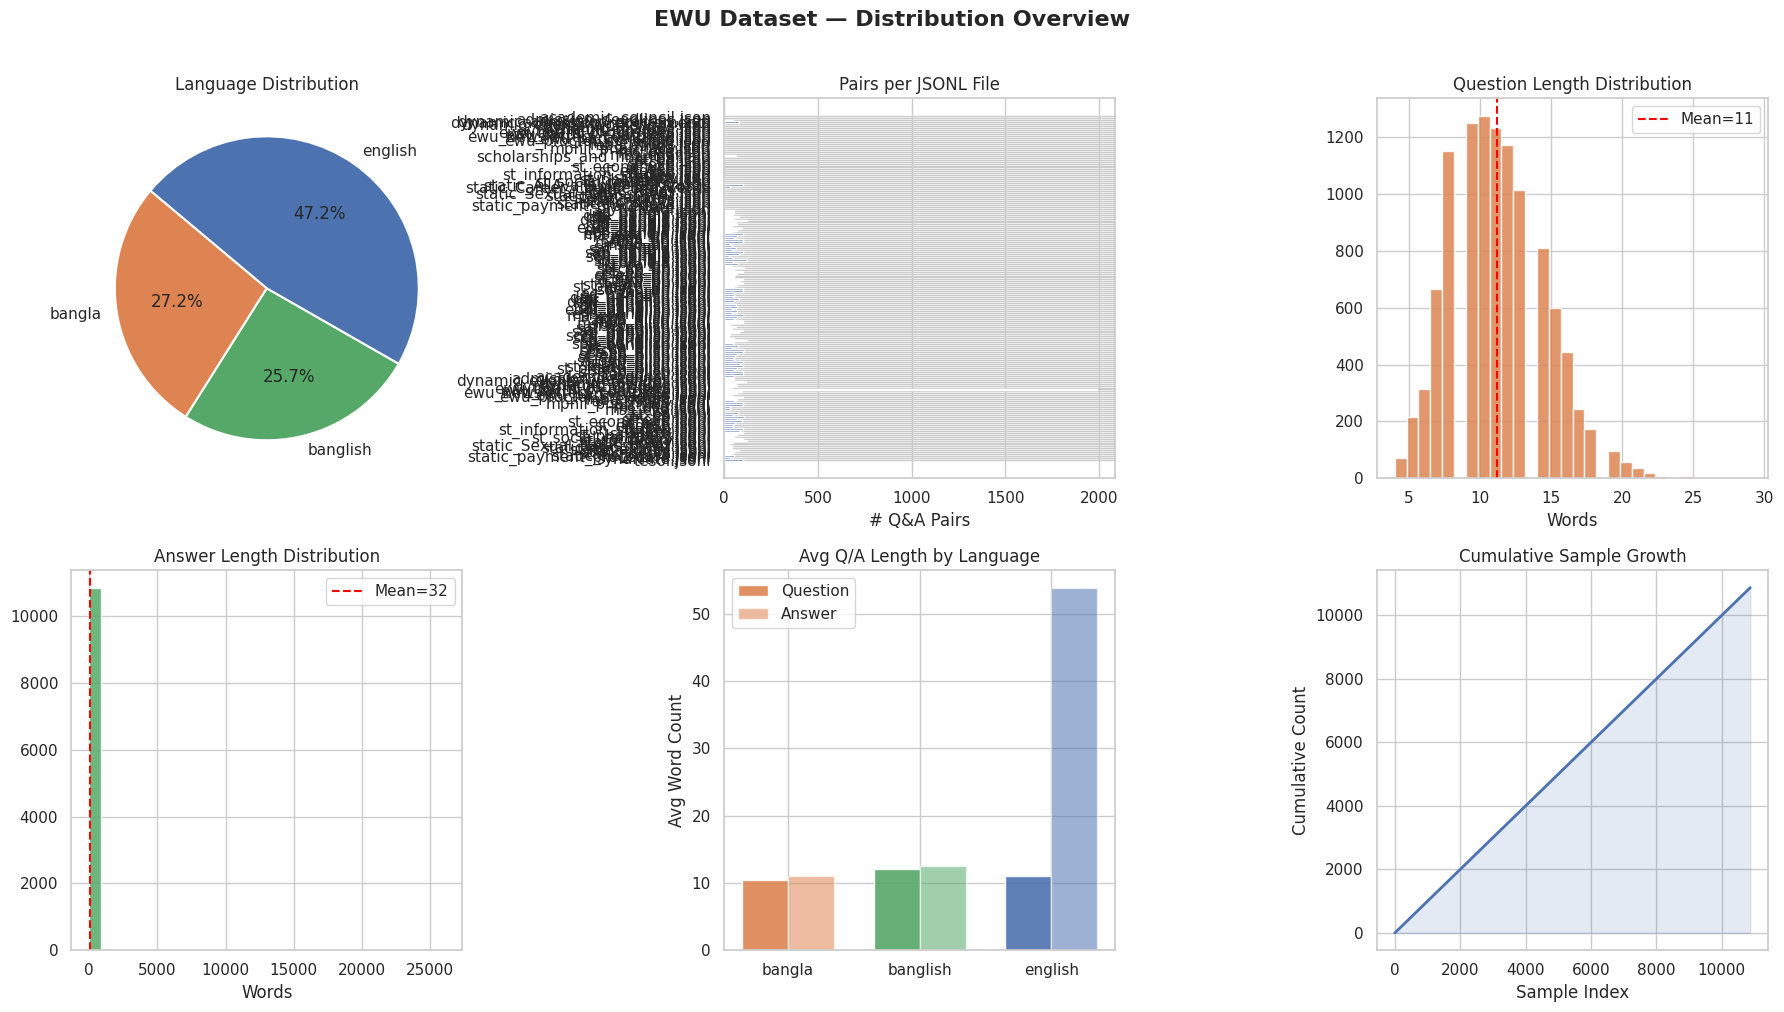

📊 Distribution plots saved to paper_assets/.


In [6]:
# ── Plots ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EWU Dataset — Distribution Overview', fontsize=16, fontweight='bold', y=1.01)

COLORS = {'english': '#4C72B0', 'bangla': '#DD8452', 'banglish': '#55A868'}

# 1. Language pie
ax = axes[0, 0]
labels = list(lang_counts.keys())
sizes  = [lang_counts[l] for l in labels]
clrs   = [COLORS.get(l, '#aaa') for l in labels]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=clrs,
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Language Distribution')

# 2. Pairs per file
ax = axes[0, 1]
tags_short = [t.split('/')[-1][:30] for t in file_stats.keys()]
pair_cnts  = [v['pairs'] for v in file_stats.values()]
ax.barh(tags_short, pair_cnts, color='#4C72B0', edgecolor='white')
ax.set_xlabel('# Q&A Pairs')
ax.set_title('Pairs per JSONL File')
ax.invert_yaxis()

# 3. Question length histogram
ax = axes[0, 2]
ax.hist(input_lens, bins=30, color='#DD8452', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(input_lens), color='red', linestyle='--', label=f'Mean={np.mean(input_lens):.0f}')
ax.set_xlabel('Words')
ax.set_title('Question Length Distribution')
ax.legend()

# 4. Answer length histogram
ax = axes[1, 0]
ax.hist(output_lens, bins=30, color='#55A868', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(output_lens), color='red', linestyle='--', label=f'Mean={np.mean(output_lens):.0f}')
ax.set_xlabel('Words')
ax.set_title('Answer Length Distribution')
ax.legend()

# 5. Stacked bar — Q & A lengths by language
ax = axes[1, 1]
lang_q_lens = {l: [] for l in lang_counts}
lang_a_lens = {l: [] for l in lang_counts}
for q, r, l in zip(inputs, outputs, languages):
    lang_q_lens[l].append(len(q.split()))
    lang_a_lens[l].append(len(r.split()))
x = np.arange(len(lang_counts))
w = 0.35
ax.bar(x - w/2, [np.mean(lang_q_lens[l]) for l in lang_counts], w,
       color=[COLORS.get(l,'#aaa') for l in lang_counts], alpha=0.9, label='Question')
ax.bar(x + w/2, [np.mean(lang_a_lens[l]) for l in lang_counts], w,
       color=[COLORS.get(l,'#aaa') for l in lang_counts], alpha=0.55, label='Answer')
ax.set_xticks(x)
ax.set_xticklabels(list(lang_counts.keys()))
ax.set_ylabel('Avg Word Count')
ax.set_title('Avg Q/A Length by Language')
ax.legend()

# 6. Cumulative sample count
ax = axes[1, 2]
ax.plot(np.cumsum([1]*len(inputs)), color='#4C72B0', linewidth=2)
ax.fill_between(range(len(inputs)), np.cumsum([1]*len(inputs)), alpha=0.15, color='#4C72B0')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cumulative Count')
ax.set_title('Cumulative Sample Growth')

plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, 'fig_data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('📊 Distribution plots saved to paper_assets/.')


## 4.1 · Language-Label Spot-Check

Language labels now come from the dataset's folder structure (`bangla/`, `banglish/`, `english/`), not text-content detection — trusted, since the folders were curated by hand.

This cell still samples a small stratified set per label for manual review, as a lightweight check that files ended up filed under the correct folder (e.g. an accidental Banglish file left under `english/`) before treating the per-language splits as ground truth downstream.


In [7]:
N_LANGID_SPOTCHECK_PER_LANG = 15
rng_lid = random.Random(SEED)

langid_rows = []
_lang_buckets = {}
for i, lang in enumerate(languages):
    _lang_buckets.setdefault(lang, []).append(i)

for lang, idxs in _lang_buckets.items():
    sample_idxs = rng_lid.sample(idxs, min(N_LANGID_SPOTCHECK_PER_LANG, len(idxs)))
    for i in sample_idxs:
        langid_rows.append({
            "index": i,
            "question": inputs[i],
            "predicted_language": lang,
            "is_correct_1_or_0": "",     # ← fill in by hand: 1 if predicted_language is right, else 0
            "true_language_if_wrong": "",  # ← fill in only if is_correct_1_or_0 == 0
        })

langid_df = pd.DataFrame(langid_rows)
langid_path = os.path.join(PAPER_ASSETS_DIR, "language_detection_spotcheck_BLANK.csv")
langid_df.to_csv(langid_path, index=False)
print(f"Blank spot-check sheet written: {langid_path}  ({len(langid_df)} items, "
      f"{N_LANGID_SPOTCHECK_PER_LANG} per detected language)")
print("Fill in is_correct_1_or_0 by hand, save as ..._FILLED.csv in the same folder, then run the next cell.")


Blank spot-check sheet written: /kaggle/working/paper_assets/language_detection_spotcheck_BLANK.csv  (45 items, 15 per detected language)
Fill in is_correct_1_or_0 by hand, save as ..._FILLED.csv in the same folder, then run the next cell.


In [8]:
filled_langid_path = os.path.join(PAPER_ASSETS_DIR, "language_detection_spotcheck_FILLED.csv")

if not os.path.exists(filled_langid_path):
    print(f"{filled_langid_path} not found yet — this cell is a no-op until the spot-check sheet above "
          f"is manually filled in and saved with the _FILLED suffix.")
else:
    filled = pd.read_csv(filled_langid_path)
    filled["is_correct_1_or_0"] = filled["is_correct_1_or_0"].astype(int)
    overall_acc = filled["is_correct_1_or_0"].mean()
    print(f"Overall language-label accuracy on the spot-check sample: {overall_acc*100:.1f}% "
          f"(n={len(filled)})")
    print("\nBy predicted language:")
    for lang, grp in filled.groupby("predicted_language"):
        acc = grp["is_correct_1_or_0"].mean()
        print(f"  {lang:<10}: {acc*100:>5.1f}%  (n={len(grp)})")

    misclassified = filled[filled["is_correct_1_or_0"] == 0]
    if len(misclassified) > 0:
        print(f"\n{len(misclassified)} misclassification(s) found — report this rate in the paper's data")
        print("section as a known limitation of the Unicode-heuristic language detector, e.g.:")
        print(f'  "Manual review of {len(filled)} randomly sampled items found the language-detection')
        print(f'   heuristic to be {overall_acc*100:.1f}% accurate, with errors concentrated in "')
        print( "   {predicted language(s) with lowest accuracy}.\"")
        misclassified.to_csv(os.path.join(PAPER_ASSETS_DIR, "language_detection_misclassified.csv"), index=False)


/kaggle/working/paper_assets/language_detection_spotcheck_FILLED.csv not found yet — this cell is a no-op until the spot-check sheet above is manually filled in and saved with the _FILLED suffix.


## 5 · Stratified Train / Val / Test Split + Leakage Audit
The original pipeline split data into train/val only and then evaluated on the validation set — the same
set used for early stopping. That is data leakage for reporting purposes: the checkpoint you keep is the
one the validation set already liked best, so validation-set metrics overstate real generalization.

Here we carve out a **third, genuinely held-out test split** (stratified by language) that the model never
sees during training or model selection, and audit it for **near-duplicate leakage** from the training set
using fuzzy string matching (typo/paraphrase-tolerant, unlike exact-match dedup).

In [9]:
# ── 3-way stratified split (by language) ──────────────────────────────────────
random.seed(SEED)

lang_to_indices = {}
for i, lang in enumerate(languages):
    lang_to_indices.setdefault(lang, []).append(i)

train_idx, val_idx, test_idx = [], [], []
for lang, idxs in lang_to_indices.items():
    idxs = idxs[:]
    random.shuffle(idxs)
    n = len(idxs)
    n_test = max(1, int(round(TEST_FRACTION_OF_TOTAL * n)))
    n_val  = max(1, int(round(VAL_FRACTION_OF_TOTAL * n)))
    test_idx.extend(idxs[:n_test])
    val_idx.extend(idxs[n_test:n_test + n_val])
    train_idx.extend(idxs[n_test + n_val:])

random.shuffle(train_idx); random.shuffle(val_idx); random.shuffle(test_idx)

print(f"Train: {len(train_idx)}   Val: {len(val_idx)}   Test: {len(test_idx)}\n")
print("Per-language breakdown:")
for lang in lang_to_indices:
    tr = sum(1 for i in train_idx if languages[i] == lang)
    va = sum(1 for i in val_idx if languages[i] == lang)
    te = sum(1 for i in test_idx if languages[i] == lang)
    print(f"  {lang:<10}: train={tr:>5d}   val={va:>4d}   test={te:>4d}")

# ── Leakage audit: near-duplicate prompts between TRAIN and TEST ──────────────
# A model can look deceptively good on test purely by having memorized a near-
# identical training prompt. We fuzzy-match every test prompt against every
# train prompt (token_sort_ratio, robust to word order / minor edits) and flag
# pairs above LEAKAGE_SIM_THRESHOLD. rapidfuzz's C implementation makes the
# O(|test| x |train|) comparison tractable (a couple of minutes on CPU here).
train_prompts_norm = [_norm(inputs[i]) for i in train_idx]
leaked_test_idx = []
for ti in tqdm(test_idx, desc="Leakage scan (test vs train)"):
    q = _norm(inputs[ti])
    match = process.extractOne(q, train_prompts_norm, scorer=rf_fuzz.token_sort_ratio)
    if match is not None and match[1] >= LEAKAGE_SIM_THRESHOLD:
        leaked_test_idx.append((ti, match[1]))

print(f"\n⚠️  {len(leaked_test_idx)} / {len(test_idx)} test prompts "
      f"({len(leaked_test_idx)/max(len(test_idx),1)*100:.1f}%) are near-duplicates "
      f"(similarity ≥ {LEAKAGE_SIM_THRESHOLD}) of a training prompt.")

if leaked_test_idx:
    leaked_set = {i for i, _ in leaked_test_idx}
    test_idx = [i for i in test_idx if i not in leaked_set]
    print(f"   → Removed from TEST set. Clean, leakage-audited test size: {len(test_idx)}")
    print("   Report this leakage rate in the paper's data / limitations section.")
else:
    print("   → No leakage detected at this threshold; test set kept as-is.")

with open(os.path.join(PAPER_ASSETS_DIR, "split_and_leakage_summary.json"), "w") as f:
    json.dump({
        "train_size": len(train_idx), "val_size": len(val_idx), "test_size": len(test_idx),
        "leaked_removed": len(leaked_test_idx), "leakage_threshold": LEAKAGE_SIM_THRESHOLD,
    }, f, indent=2)


Train: 8703   Val: 1087   Test: 1087

Per-language breakdown:
  bangla    : train= 2364   val= 295   test= 295
  banglish  : train= 2235   val= 279   test= 279
  english   : train= 4104   val= 513   test= 513


Leakage scan (test vs train):   0%|          | 0/1087 [00:00<?, ?it/s]


⚠️  197 / 1087 test prompts (18.1%) are near-duplicates (similarity ≥ 90) of a training prompt.
   → Removed from TEST set. Clean, leakage-audited test size: 890
   Report this leakage rate in the paper's data / limitations section.


## 6 · Prepare HuggingFace Dataset (train/val only — test stays untouched)

In [10]:
# ── System prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are EWU Assistant, the official virtual assistant for "
    "East West University (EWU), Dhaka, Bangladesh. "
    "Answer in the same language the user writes — "
    "Bengali (\u09ac\u09be\u0982\u09b2\u09be), Banglish, or English. "
    "STRICT RULES: "
    "1. Answer ONLY using facts you learned about EWU during training. "
    "2. Always include 'EWU' or 'East West University' in your answer. "
    "3. If unsure, respond: 'I don't have that information. "
    "Please contact EWU at info@ewubd.edu or visit ewubd.edu.' "
    "4. NEVER invent names, dates, fees, or numbers. "
    "5. Keep answers concise and factual."
)

def format_chat(prompt: str, response: str) -> str:
    '''Format a single Q/A pair as a Qwen2 chat string.'''
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{prompt}<|im_end|>\n"
        f"<|im_start|>assistant\n{response}<|im_end|>"
    )

formatted = [format_chat(p, r) for p, r in zip(inputs, outputs)]

train_texts = [formatted[i] for i in train_idx]
val_texts   = [formatted[i] for i in val_idx]

train_dataset = Dataset.from_dict({"text": train_texts})
val_dataset   = Dataset.from_dict({"text": val_texts})

# Raw (unformatted) TEST split — held out entirely, used only for final evaluation
test_prompts    = [inputs[i] for i in test_idx]
test_references = [outputs[i] for i in test_idx]
test_langs      = [languages[i] for i in test_idx]

print(f"Train : {len(train_dataset):>5d} samples")
print(f"Val   : {len(val_dataset):>5d} samples  (early stopping / model selection only)")
print(f"Test  : {len(test_prompts):>5d} samples  (NEVER seen until final evaluation)")

print("\nExample formatted training sample:")
print(train_dataset[0]['text'][:400], '...')


Train :  8703 samples
Val   :  1087 samples  (early stopping / model selection only)
Test  :   890 samples  (NEVER seen until final evaluation)

Example formatted training sample:
<|im_start|>system
You are EWU Assistant, the official virtual assistant for East West University (EWU), Dhaka, Bangladesh. Answer in the same language the user writes — Bengali (বাংলা), Banglish, or English. STRICT RULES: 1. Answer ONLY using facts you learned about EWU during training. 2. Always include 'EWU' or 'East West University' in your answer. 3. If unsure, respond: 'I don't have that inf ...


## 7 · Load Tokenizer & Base Model (4-bit QLoRA)

In [11]:
# ── BitsAndBytes 4-bit config for T4 ─────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4 does NOT support bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    padding_side='right',
)
tokenizer.pad_token = tokenizer.eos_token

def load_fresh_base_model():
    '''(Re)load the quantized base model. Used once up-front, and again for each
    extra entry in RANDOM_SEEDS so multi-seed runs start from an unmodified base.'''
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
        attn_implementation="eager",   # T4: no flash-attn; eager is stable & fast enough
    )
    m.config.use_cache = False
    m.config.pretraining_tp = 1
    return m

base_model = load_fresh_base_model()
print(f"✅ Base model loaded  |  dtype: {next(base_model.parameters()).dtype}")
total_params = sum(p.numel() for p in base_model.parameters())
print(f"   Total params : {total_params/1e9:.2f} B")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Base model loaded  |  dtype: torch.float16
   Total params : 1.70 B


## 7.1 · Tokenizer Efficiency by Language

Qwen2.5's BPE vocabulary was trained on a corpus that skews heavily English/Chinese; it's known that
subword tokenizers fragment non-Latin, lower-resource scripts into more tokens per word than English
("subword fertility" — see e.g. Rust et al. 2021, *"How Good is Your Tokenizer?"*, ACL). That has two
concrete consequences worth measuring rather than assuming: (1) Bangla questions/answers eat more of the
`MAX_SEQ_LEN` budget, raising truncation risk for the same word count, and (2) Bangla generation is slower
and costs more compute per answer than English of equivalent length.

In [12]:
tok_efficiency_rows = []
for lang in sorted(set(languages)):
    lang_idxs = [i for i, l in enumerate(languages) if l == lang]
    sample_idxs = random.Random(SEED).sample(lang_idxs, min(300, len(lang_idxs)))
    ratios = []
    for i in sample_idxs:
        text = inputs[i] + " " + outputs[i]
        n_words = len(text.split())
        n_tokens = len(tokenizer(text, add_special_tokens=False)["input_ids"])
        if n_words > 0:
            ratios.append(n_tokens / n_words)
    tok_efficiency_rows.append({
        "language": lang, "n_sampled": len(ratios),
        "avg_tokens_per_word": round(float(np.mean(ratios)), 2),
        "std_tokens_per_word": round(float(np.std(ratios)), 2),
    })

tok_eff_df = pd.DataFrame(tok_efficiency_rows)
print(tok_eff_df.to_string(index=False))
tok_eff_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "tokenizer_efficiency_by_language.csv"), index=False)

baseline_ratio = tok_eff_df.loc[tok_eff_df["language"] == "english", "avg_tokens_per_word"].values
if len(baseline_ratio) and baseline_ratio[0] > 0:
    print("\nRelative fertility vs. English (>1.0 means that language costs more tokens per word):")
    for _, row in tok_eff_df.iterrows():
        print(f"  {row['language']:<10}: {row['avg_tokens_per_word'] / baseline_ratio[0]:.2f}x")
print("\nIf Bangla/Banglish ratios are notably >1x, consider this when interpreting Avg_Gen_Length_w")
print("(word count) differences across languages, and when setting MAX_SEQ_LEN for training.")


language  n_sampled  avg_tokens_per_word  std_tokens_per_word
  bangla        300                 6.59                 1.36
banglish        300                 1.99                 0.41
 english        300                 1.64                 0.63

Relative fertility vs. English (>1.0 means that language costs more tokens per word):
  bangla    : 4.02x
  banglish  : 1.21x
  english   : 1.00x

If Bangla/Banglish ratios are notably >1x, consider this when interpreting Avg_Gen_Length_w
(word count) differences across languages, and when setting MAX_SEQ_LEN for training.


## 8 · Shared Evaluation Utilities
One metrics function is reused for baseline, fine-tuned, and RAG-augmented evaluation so every system is
scored identically. Bootstrap helpers give confidence intervals and a paired significance test for
comparing any two systems on the same test items.

In [13]:
# ── EWU domain keywords for Domain Hit % ─────────────────────────────────────
EWU_KEYWORDS = [
    # English
    'ewu', 'east west university', 'admission', 'semester', 'tuition',
    'credit', 'cgpa', 'department', 'faculty', 'campus', 'lab', 'library',
    'registrar', 'scholarship', 'exam', 'midterm', 'final', 'course',
    'club', 'cafeteria', 'bus', 'hall', 'dean', 'proctor',
    # Bangla transliteration
    'bhortir', 'semester', 'porikhha', 'department', 'biswabidyalay',
    # Bangla script
    'ভর্তি', 'সেমিস্টার', 'পরীক্ষা', 'বিশ্ববিদ্যালয়', 'অনুষদ',
]

def is_ewu_hit(text: str) -> bool:
    t = text.lower()
    return any(kw in t for kw in EWU_KEYWORDS)

def make_generate_fn(gen_model):
    '''Bind a generate_response()-style function to a specific model instance
    (base model for the baseline, LoRA model for fine-tuned/per-seed runs).'''
    def _generate(prompt: str, max_new_tokens: int = 200) -> str:
        chat_input = (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{prompt}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
        enc = tokenizer(chat_input, return_tensors="pt").to(gen_model.device)
        with torch.no_grad():
            out = gen_model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                temperature=0.3,
                top_p=0.9,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.convert_tokens_to_ids('<|im_end|>'),
            )
        gen_ids  = out[0][enc['input_ids'].shape[1]:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        return response.strip()
    return _generate

def compute_all_metrics(predictions, references, langs=None):
    '''Compute the 8 core metrics plus per-sample scores (needed for bootstrap
    CIs and paired significance tests) and an optional per-language breakdown.
    Returns (metrics, per_sample, metrics_by_lang).'''
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    r1, r2, rL = [], [], []
    for ref, pred in zip(references, predictions):
        sc = rouge.score(ref, pred)
        r1.append(sc['rouge1'].fmeasure)
        r2.append(sc['rouge2'].fmeasure)
        rL.append(sc['rougeL'].fmeasure)

    # Multilingual BERTScore checkpoint — the English-only default gives
    # meaningless scores on Bangla/Banglish text.
    _, _, F1_bert = bert_score_fn(
        predictions, references, model_type='bert-base-multilingual-cased',
        device=device, batch_size=8, verbose=False,
    )
    bert_f1_ps = F1_bert.tolist()

    exact   = [1 if p.strip().lower() == r.strip().lower() else 0 for p, r in zip(predictions, references)]
    gen_len = [len(p.split()) for p in predictions]
    domain_hit = [is_ewu_hit(p) for p in predictions]

    # chrF++ (character n-gram F-score + word bigrams): standard in MT/NLG evaluation and
    # notably more reliable than BLEU/ROUGE-style word-overlap metrics for morphologically
    # rich / agglutinative languages such as Bangla, and robust to Banglish's mixed script
    # (Popovic 2015, 2017; used as a primary metric in WMT since 2017).
    chrf_scorer = sacrebleu.CHRF(word_order=2)  # word_order=2 => chrF++
    chrf = [chrf_scorer.sentence_score(p, [r]).score / 100.0 for p, r in zip(predictions, references)]

    per_sample = {
        "rouge1": r1, "rouge2": r2, "rougeL": rL, "bertscore_f1": bert_f1_ps,
        "chrf++": chrf, "exact_match": exact, "gen_len": gen_len, "domain_hit": domain_hit,
    }

    metrics = {
        "ROUGE-1":            round(float(np.mean(r1)), 4),
        "ROUGE-2":            round(float(np.mean(r2)), 4),
        "ROUGE-L":            round(float(np.mean(rL)), 4),
        "BERTScore_F1":       round(float(np.mean(bert_f1_ps)), 4),
        "chrF++":             round(float(np.mean(chrf)), 4),
        "Exact_Match_pct":    round(float(np.mean(exact)) * 100, 2),
        "Avg_Gen_Length_w":   round(float(np.mean(gen_len)), 2),
        "EWU_Domain_Hit_pct": round(float(np.mean(domain_hit)) * 100, 2),
    }

    metrics_by_lang = {}
    if langs is not None:
        for lang in sorted(set(langs)):
            sel = [i for i, l in enumerate(langs) if l == lang]
            metrics_by_lang[lang] = {
                "n":                  len(sel),
                "ROUGE-1":            round(float(np.mean([r1[i] for i in sel])), 4),
                "ROUGE-L":            round(float(np.mean([rL[i] for i in sel])), 4),
                "BERTScore_F1":       round(float(np.mean([bert_f1_ps[i] for i in sel])), 4),
                "chrF++":             round(float(np.mean([chrf[i] for i in sel])), 4),
                "EWU_Domain_Hit_pct": round(float(np.mean([domain_hit[i] for i in sel])) * 100, 2),
            }
    return metrics, per_sample, metrics_by_lang

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=BOOTSTRAP_CI, seed=SEED):
    '''Percentile bootstrap 95% CI for the mean of `values`.'''
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo = np.percentile(boot_means, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return float(values.mean()), float(lo), float(hi)

def paired_bootstrap_p(scores_a, scores_b, n_boot=N_BOOTSTRAP, seed=SEED):
    '''Two-sided paired bootstrap test for mean(b) - mean(a) != 0 on matched samples.'''
    rng = np.random.default_rng(seed)
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    diff = b - a
    obs = diff.mean()
    n = len(diff)
    boot = np.array([rng.choice(diff, size=n, replace=True).mean() for _ in range(n_boot)])
    centered = boot - boot.mean()          # null distribution: shift to be centered at 0
    p = float(np.mean(np.abs(centered) >= abs(obs)))
    return float(obs), p

print("✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p")


✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p


In [14]:
# ── Resumable generation helper (added after the first full run hit Kaggle's 12-hour limit) ─────────
# The first run lost every prediction because they only lived in memory. This helper saves each answer to
# disk every few items and, when re-run, skips answers that are already done. It also stores the prompt
# with each answer, so a checkpoint is never applied to a different question.
def generate_with_checkpoint(name, gen_fn, prompts, every=10):
    path = os.path.join(PAPER_ASSETS_DIR, f"pred_ckpt_{name}.csv")
    done = {}
    if os.path.exists(path):
        d = pd.read_csv(path, keep_default_na=False)
        for i, p, r in zip(d["idx"], d["prompt"], d["response"]):
            i = int(i)
            if i < len(prompts) and p == prompts[i]:
                done[i] = r
        print(f"[{name}] resuming: {len(done)}/{len(prompts)} answers already on disk")

    def _save():
        pd.DataFrame({"idx": sorted(done), "prompt": [prompts[i] for i in sorted(done)],
                      "response": [done[i] for i in sorted(done)]}
                     ).to_csv(path, index=False, encoding="utf-8-sig")

    try:
        for i, p in enumerate(tqdm(prompts, desc=f"Generation [{name}]")):
            if i in done:
                continue
            done[i] = gen_fn(p)
            if len(done) % every == 0:
                _save()
    finally:
        _save()                                   # also on Ctrl-C / crash / timeout-kill of the loop
    return [done[i] for i in range(len(prompts))]

print("✅ generate_with_checkpoint ready — checkpoints go to", PAPER_ASSETS_DIR)

✅ generate_with_checkpoint ready — checkpoints go to /kaggle/working/paper_assets


## 8.1 · Load Category-Stratified Eval Set (Ground-Truth XLSX)

Replaces the old language-only `TEST_EVAL_SAMPLES` subset of the JSONL test split. This eval set comes from the verified `University_Chatbot_Questions...xlsx` ground-truth workbook instead — 1 question per (Category × Difficulty), giving 3 questions/category (Easy+Medium+Hard) across all 37 categories, each tested in all 3 languages: **111 questions × 3 languages = 333 tests total**.

In [15]:
corpus = pd.read_excel(GROUND_TRUTH_XLSX, sheet_name="Question Corpus")

LANGUAGE_COLUMNS = {
    "english": "English Query",
    "bangla": "Bangla Query",
    "banglish": "Banglish Query",
}

DIFFICULTY_ALIAS = {"Easy": "Simple", "Medium": "Normal", "Hard": "Complex"}
xlsx_rows = []
for _, r in corpus.iterrows():
    qnum = r["Q#"]
    for language, qcol in LANGUAGE_COLUMNS.items():
        query = r[qcol]
        if pd.isna(query) or not str(query).strip():
            continue
        xlsx_rows.append({
            "Q#": qnum, "language": language, "query": str(query).strip(),
            "Category": r.get("Category", ""), "Difficulty": r.get("Difficulty", ""),
            "Difficulty Group": DIFFICULTY_ALIAS.get(str(r.get("Difficulty", "")), str(r.get("Difficulty", ""))),
            # extra metadata carried through for the §24.1 breakdowns (ported from rasa-eval)
            "Group": r.get("Group", ""), "Query Style": r.get("Query Style", ""),
            "Noise Type": r.get("Noise Type", ""), "Intent": r.get("Intent", ""),
            "Ground Truth Type": r.get("Ground Truth Type", ""),
            "ground_truth": str(r["Ground Truth Answer (Canonical English)"]).strip(),
        })

xlsx_test_df = pd.DataFrame(xlsx_rows)
assert len(xlsx_test_df) == 3330, f"Expected 3,330 rows (1,110 questions × 3 languages); found {len(xlsx_test_df)}"

# One question per (Category, Difficulty) — every category has Easy/Medium/Hard, so this
# guarantees difficulty coverage rather than category-only random picks that could skew.
selected_qnums = (
    corpus.groupby(["Category", "Difficulty"], dropna=False)["Q#"]
    .apply(lambda s: s.sample(n=min(QUESTIONS_PER_DIFFICULTY, len(s)), random_state=SEED))
    .reset_index(drop=True)
)
assert selected_qnums.duplicated().sum() == 0, "Unexpected duplicate Q# across category/difficulty groups"

xlsx_eval_df = (
    xlsx_test_df[xlsx_test_df["Q#"].isin(selected_qnums)]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

test_prompts_eval     = xlsx_eval_df["query"].tolist()
test_references_eval  = xlsx_eval_df["ground_truth"].tolist()
test_langs_eval       = xlsx_eval_df["language"].tolist()

# Kept for compatibility with later cells (README export, reproducibility appendix) that report
# `len(eval_test_idx)` — this eval set no longer comes from `test_idx` (the JSONL train/val/test
# split), so it's just a plain 0..N-1 index over `xlsx_eval_df`.
eval_test_idx = list(range(len(xlsx_eval_df)))

print(f"Eval set (from ground-truth XLSX): {len(xlsx_eval_df)} tests "
      f"({xlsx_eval_df['Q#'].nunique()} questions × {xlsx_eval_df['language'].nunique()} languages)")
print("\nQuestions selected per category:")
print(xlsx_eval_df.groupby("Category")["Q#"].nunique())
print("\nLanguage breakdown:")
print(xlsx_eval_df["language"].value_counts())


Eval set (from ground-truth XLSX): 333 tests (111 questions × 3 languages)

Questions selected per category:
Category
Academics & Policies                                                          3
Admission & Application                                                       3
BBA Department                                                                3
CSE Department                                                                3
Campus Life & Facilities                                                      3
Civil Engineering Department                                                  3
Data Science Department                                                       3
EEE Department                                                                3
Economics Department                                                          3
English Department                                                            3
Faculty & Contact                                                             3
Fe

## 9 · Zero-Shot BASELINE Evaluation (before fine-tuning)
Run on a stratified subset of the held-out **test** split, using the untouched base model. This is the
number fine-tuning has to beat.

In [16]:
base_model.eval()
base_model.config.use_cache = True   # needed for generation
generate_baseline = make_generate_fn(base_model)

print("\nGenerating zero-shot baseline predictions ...")
baseline_predictions = generate_with_checkpoint("baseline", generate_baseline, test_prompts_eval)

baseline_metrics, baseline_per_sample, baseline_by_lang = compute_all_metrics(
    baseline_predictions, test_references_eval, test_langs_eval)

base_model.config.use_cache = False  # back off for training

print("\n" + "═"*50)
print("  ZERO-SHOT BASELINE RESULTS")
print("═"*50)
for k, v in baseline_metrics.items():
    print(f"  {k:<22}  {v}")
print("═"*50)



Generating zero-shot baseline predictions ...


Generation [baseline]:   0%|          | 0/333 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


══════════════════════════════════════════════════
  ZERO-SHOT BASELINE RESULTS
══════════════════════════════════════════════════
  ROUGE-1                 0.0728
  ROUGE-2                 0.0102
  ROUGE-L                 0.0448
  BERTScore_F1            0.6223
  chrF++                  0.0888
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        46.9
  EWU_Domain_Hit_pct      90.69
══════════════════════════════════════════════════


## 10 · LoRA Configuration

In [17]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
print("LoRA config ready — attached per training run in the next cell.")


LoRA config ready — attached per training run in the next cell.


## 11 · Training
Wrapped so `RANDOM_SEEDS` can hold more than one value for a multi-seed variance report. The first seed's
model/trainer become the "main" `model`/`trainer` used by the rest of the notebook (adapter export, RAG,
etc.); any additional seeds are trained purely to report variance and are not exported.

**Resumed run** — training already completed in a prior session; this cell loads the saved LoRA adapter instead of retraining, then reconstructs the few variables (`ft_predictions`, `ft_metrics`, etc.) that later sections expect, by running one generation pass over the held-out eval subset (the 333-test category-stratified set loaded in section 8.1) with the loaded adapter.


In [18]:
# -- Resume from saved checkpoint instead of training -------------------------
ADAPTER_CHECKPOINT_DIR = "/kaggle/input/datasets/mrnotalent/ewu-qwen-adapter-checkpoint1632"  # <-- EDIT if your mount path differs

from peft import PeftModel

print(f"Loading LoRA adapter from: {ADAPTER_CHECKPOINT_DIR}")
model = PeftModel.from_pretrained(base_model, ADAPTER_CHECKPOINT_DIR)
model.eval()
model.config.use_cache = True

# Re-load tokenizer from the checkpoint in case special/added tokens differ
# from the base tokenizer already loaded in Section 7 (harmless if identical).
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_CHECKPOINT_DIR, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

generate_response = make_generate_fn(model)   # main generation function used from here on

print("Generating fine-tuned predictions on the held-out eval subset ...")
ft_predictions = generate_with_checkpoint("ft", generate_response, test_prompts_eval)
model.config.use_cache = False

ft_metrics, ft_per_sample, ft_metrics_by_lang = compute_all_metrics(
    ft_predictions, test_references_eval, test_langs_eval)

print("\n" + "="*50)
print("  FINE-TUNED RESULTS (resumed from saved adapter)")
print("="*50)
for k, v in ft_metrics.items():
    print(f"  {k:<22}  {v}")
print("="*50)

# -- Reconstruct training-history variables from trainer_state.json ----------
# Not strictly needed for downstream metrics, but Section 12/13 plotting cells
# reference these names, so we populate them from the saved trainer state
# rather than leaving them undefined.
import json as _json

TRAINER_STATE_PATH = os.path.join(ADAPTER_CHECKPOINT_DIR, "trainer_state.json")
train_losses, val_losses, step_log = [], [], []
train_result = None

if os.path.exists(TRAINER_STATE_PATH):
    with open(TRAINER_STATE_PATH) as f:
        _ts = _json.load(f)
    for entry in _ts.get("log_history", []):
        step = entry.get("step")
        if step is None:
            continue
        if "loss" in entry:
            step_log.append(step)
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            val_losses.append((step, entry["eval_loss"]))
    print(f"Reconstructed {len(train_losses)} train-loss points and "
          f"{len(val_losses)} eval-loss points from trainer_state.json")
else:
    print(f"NOTE: trainer_state.json not found at {TRAINER_STATE_PATH} — "
          f"training-loss plots in later cells may be empty. Re-upload it "
          f"alongside the adapter files if you want those plots populated.")

main_train_wall_sec = None  # unknown in a resumed run; wall-time cells will show N/A

# seed_run_results / multi-seed variance block expects this structure even for
# a single seed — populate minimally so nothing downstream KeyErrors.
seed_run_results = {
    RANDOM_SEEDS[0]: {
        "metrics": ft_metrics,
        "final_train_loss": (train_losses[-1] if train_losses else None),
        "train_wall_sec": main_train_wall_sec,
    }
}

print("\nMULTI-SEED VARIANCE  (single seed — no variance to report)")


Loading LoRA adapter from: /kaggle/input/datasets/mrnotalent/ewu-qwen-adapter-checkpoint1632
Generating fine-tuned predictions on the held-out eval subset ...


Generation [ft]:   0%|          | 0/333 [00:00<?, ?it/s]


  FINE-TUNED RESULTS (resumed from saved adapter)
  ROUGE-1                 0.0852
  ROUGE-2                 0.0135
  ROUGE-L                 0.0565
  BERTScore_F1            0.597
  chrF++                  0.1509
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        86.55
  EWU_Domain_Hit_pct      66.07
Reconstructed 163 train-loss points and 3 eval-loss points from trainer_state.json

MULTI-SEED VARIANCE  (single seed — no variance to report)


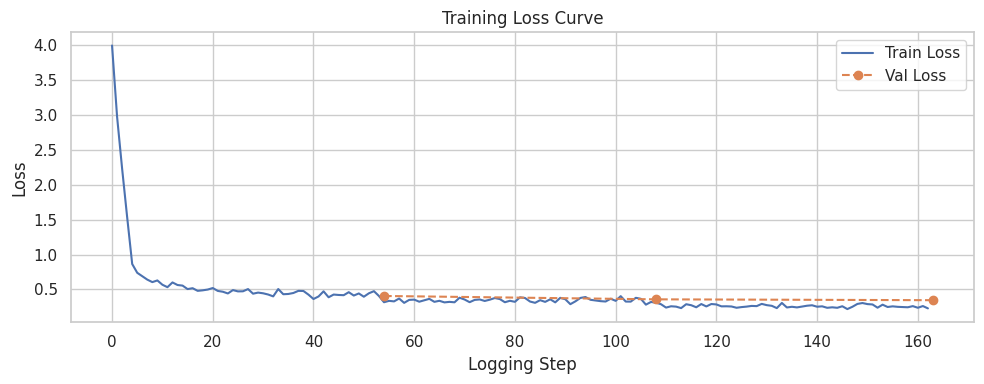

📊 Loss curve saved.


In [19]:
# ── Plot training loss (seed 0 / main run) ────────────────────────────────────
if train_losses:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='Train Loss', color='#4C72B0', linewidth=1.5)
    if val_losses:
        vx, vy = zip(*val_losses)
        norm_x = [int(v / max(step_log or [1]) * len(train_losses)) for v in vx]
        ax.plot(norm_x, vy, 'o--', label='Val Loss', color='#DD8452', linewidth=1.5)
    ax.set_xlabel('Logging Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Curve')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PAPER_ASSETS_DIR, 'fig_training_loss.png'), dpi=150)
    plt.show()
    print('📊 Loss curve saved.')


## 12 · Fine-tuned Evaluation on the Held-Out TEST Set
`ft_metrics` / `ft_per_sample` were already computed inside the training loop above (seed 0, on the exact
same `test_prompts_eval` used for the baseline), so the two systems are compared on identical items.

In [20]:
print("\n" + "═"*50)
print("  FINE-TUNED RESULTS (held-out TEST set)")
print("═"*50)
for k, v in ft_metrics.items():
    print(f"  {k:<22}  {v}")
print("═"*50)

print("\n" + "═"*68)
print("  FINE-TUNED RESULTS BY LANGUAGE")
print("═"*68)
header = f"  {'lang':<10}{'n':>4}  {'ROUGE-1':>8}  {'ROUGE-L':>8}  {'chrF++':>8}  {'BERTScore':>10}  {'Domain Hit%':>12}"
print(header)
for lang, m in ft_metrics_by_lang.items():
    print(f"  {lang:<10}{m['n']:>4}  {m['ROUGE-1']:>8}  {m['ROUGE-L']:>8}  {m['chrF++']:>8}  "
          f"{m['BERTScore_F1']:>10}  {m['EWU_Domain_Hit_pct']:>12}")
print("═"*68)



══════════════════════════════════════════════════
  FINE-TUNED RESULTS (held-out TEST set)
══════════════════════════════════════════════════
  ROUGE-1                 0.0852
  ROUGE-2                 0.0135
  ROUGE-L                 0.0565
  BERTScore_F1            0.597
  chrF++                  0.1509
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        86.55
  EWU_Domain_Hit_pct      66.07
══════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════
  FINE-TUNED RESULTS BY LANGUAGE
════════════════════════════════════════════════════════════════════
  lang         n   ROUGE-1   ROUGE-L    chrF++   BERTScore   Domain Hit%
  bangla     111    0.0041    0.0041     0.003      0.6065         23.42
  banglish   111    0.0632    0.0507     0.184      0.5501         78.38
  english    111    0.1884    0.1149    0.2657      0.6343          96.4
════════════════════════════════════════════════════════════════════


### 12.1 · Statistical Significance — Baseline vs Fine-tuned

In [21]:
print("Statistical comparison: BASELINE (zero-shot) vs FINE-TUNED, matched on the same test items\n")

comparison_rows = []
for metric_key, label in [("rouge1", "ROUGE-1"), ("rougeL", "ROUGE-L"), ("chrf++", "chrF++"), ("bertscore_f1", "BERTScore F1")]:
    a = baseline_per_sample[metric_key]
    b = ft_per_sample[metric_key]
    mean_a, lo_a, hi_a = bootstrap_ci(a)
    mean_b, lo_b, hi_b = bootstrap_ci(b)
    diff, p_boot = paired_bootstrap_p(a, b)
    try:
        _, p_wilcoxon = wilcoxon(a, b)
    except ValueError:
        p_wilcoxon = float('nan')
    comparison_rows.append({
        "metric": label,
        "baseline_mean": round(mean_a, 4), "baseline_95ci": f"[{lo_a:.4f}, {hi_a:.4f}]",
        "finetuned_mean": round(mean_b, 4), "finetuned_95ci": f"[{lo_b:.4f}, {hi_b:.4f}]",
        "delta": round(diff, 4),
        "p_bootstrap": round(p_boot, 4),
        "p_wilcoxon": (round(p_wilcoxon, 4) if not np.isnan(p_wilcoxon) else None),
        "significant_at_0.05": bool(p_boot < 0.05),
    })

sig_df = pd.DataFrame(comparison_rows)
print(sig_df.to_string(index=False))
sig_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "baseline_vs_finetuned_significance.csv"), index=False)
print(f"\nSaved → {PAPER_ASSETS_DIR}/baseline_vs_finetuned_significance.csv")


Statistical comparison: BASELINE (zero-shot) vs FINE-TUNED, matched on the same test items

      metric  baseline_mean    baseline_95ci  finetuned_mean   finetuned_95ci   delta  p_bootstrap  p_wilcoxon  significant_at_0.05
     ROUGE-1         0.0728 [0.0614, 0.0845]          0.0852 [0.0762, 0.0955]  0.0124        0.001      0.0007                 True
     ROUGE-L         0.0448 [0.0384, 0.0517]          0.0565 [0.0509, 0.0626]  0.0117        0.000      0.0000                 True
      chrF++         0.0888 [0.0755, 0.1019]          0.1509 [0.1384, 0.1630]  0.0621        0.000      0.0000                 True
BERTScore F1         0.6223 [0.6181, 0.6265]          0.5970 [0.5921, 0.6017] -0.0254        0.000      0.0000                 True

Saved → /kaggle/working/paper_assets/baseline_vs_finetuned_significance.csv


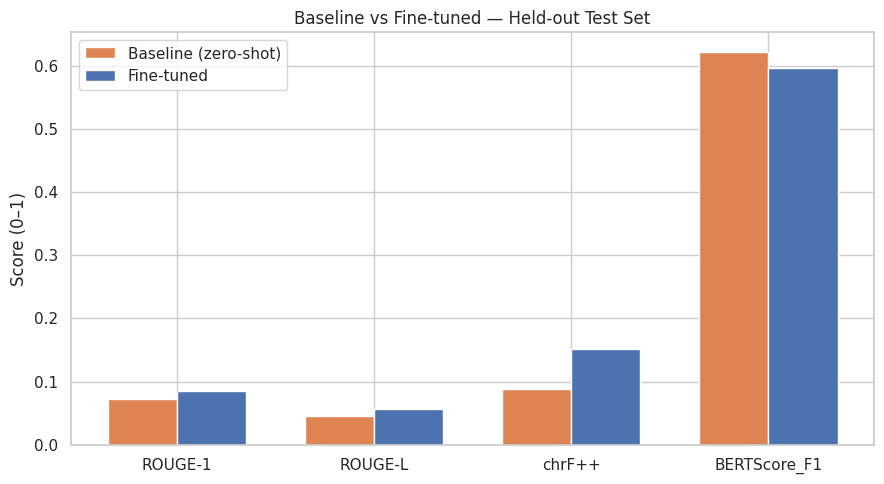

In [22]:
# ── Metric bar chart (baseline vs fine-tuned) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["ROUGE-1", "ROUGE-L", "chrF++", "BERTScore_F1"]
x = np.arange(len(metrics_to_plot)); w = 0.35
ax.bar(x - w/2, [baseline_metrics[m] for m in metrics_to_plot], w, label="Baseline (zero-shot)", color="#DD8452")
ax.bar(x + w/2, [ft_metrics[m] for m in metrics_to_plot], w, label="Fine-tuned", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score (0–1)")
ax.set_title("Baseline vs Fine-tuned — Held-out Test Set")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_baseline_vs_finetuned.png"), dpi=150)
plt.show()


## 13 · Qualitative Error Analysis

In [23]:
N_WORST = 10
worst_idx = np.argsort(ft_per_sample["bertscore_f1"])[:N_WORST]

def _looks_like_refusal(text: str) -> bool:
    t = text.lower()
    return ("don't have that information" in t) or ("contact ewu" in t and len(t.split()) < 25)

error_rows = []
for i in worst_idx:
    error_rows.append({
        "language":      test_langs_eval[i],
        "question":      test_prompts_eval[i],
        "reference":     test_references_eval[i],
        "prediction":    ft_predictions[i],
        "bertscore_f1":  round(ft_per_sample["bertscore_f1"][i], 4),
        "rougeL":        round(ft_per_sample["rougeL"][i], 4),
        "is_refusal":    _looks_like_refusal(ft_predictions[i]),
        "is_domain_hit": ft_per_sample["domain_hit"][i],
    })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "worst_10_error_cases.csv"), index=False)
print(f"Worst {N_WORST} cases by BERTScore F1 (full text saved to paper_assets/worst_10_error_cases.csv):\n")
print(error_df[["language", "bertscore_f1", "rougeL", "is_refusal", "is_domain_hit"]].to_string(index=False))

refusal_rate = float(np.mean([_looks_like_refusal(p) for p in ft_predictions])) * 100
domain_miss_rate = 100 - ft_metrics["EWU_Domain_Hit_pct"]
print(f"\nOverall refusal rate on test set : {refusal_rate:.1f}%")
print(f"Overall domain-miss rate         : {domain_miss_rate:.1f}%  "
      f"(answers that never mention EWU / East West University)")


Worst 10 cases by BERTScore F1 (full text saved to paper_assets/worst_10_error_cases.csv):

language  bertscore_f1  rougeL  is_refusal  is_domain_hit
banglish        0.4667  0.0000       False          False
banglish        0.4674  0.0000       False          False
banglish        0.4884  0.0000       False          False
banglish        0.4889  0.0204       False          False
banglish        0.4953  0.0000       False           True
banglish        0.5008  0.0000       False          False
banglish        0.5019  0.0147       False           True
banglish        0.5067  0.0000       False           True
banglish        0.5072  0.0206       False          False
banglish        0.5090  0.0441       False           True

Overall refusal rate on test set : 0.0%
Overall domain-miss rate         : 33.9%  (answers that never mention EWU / East West University)


## 13.1 · Human Evaluation Rubric + Inter-Annotator Agreement

**Why this matters:** a 2024 comparison of LLM fine-tuning/evaluation methods on a travel chatbot found
that automatic metrics and even RAGAS-style scores **did not align with human judgment**, and that GPT-4
evaluation aligned best with humans among automatic methods — with the authors concluding *"it is
essential to keep humans in the loop for evaluation"* (Meyer et al., 2024, arXiv:2408.03562). ROUGE and
BERTScore reward surface-level overlap with the reference, not whether the answer is actually correct,
helpful, or safe. Reviewers of a chatbot paper will expect at least a small human evaluation.

This cell exports a **blank annotation sheet** for 2+ human raters (you and a co-author, or two native
Bangla/English speakers) to independently score a random sample of the fine-tuned model's answers on a
5-point Likert scale across four axes, following the standard set used in chatbot evaluation studies:

| Axis | 1 (worst) | 5 (best) |
|---|---|---|
| **Correctness** | Factually wrong / contradicts EWU facts | Fully correct |
| **Helpfulness** | Doesn't address the question at all | Fully answers what was asked |
| **Fluency** | Broken / unreadable in the target language | Native-sounding |
| **Faithfulness** | Invents facts not in training data/KB | Fully grounded, no fabrication |

Once ≥2 annotators fill in their copies, the second cell computes **Krippendorff's alpha** (handles
ordinal Likert data and any number of raters, unlike Cohen's kappa which needs exactly 2) as the
inter-annotator agreement statistic to report alongside mean scores.

In [24]:
N_HUMAN_EVAL_SAMPLES = 50   # small enough for 1-2 people to actually annotate; raise if you have capacity
rng_he = random.Random(SEED)
he_indices = rng_he.sample(range(len(test_prompts_eval)), min(N_HUMAN_EVAL_SAMPLES, len(test_prompts_eval)))

human_eval_template = pd.DataFrame([
    {
        "item_id": i,
        "language": test_langs_eval[i],
        "question": test_prompts_eval[i],
        "reference_answer": test_references_eval[i],
        "model_answer": ft_predictions[i],
        "correctness_1to5": "",
        "helpfulness_1to5": "",
        "fluency_1to5": "",
        "faithfulness_1to5": "",
        "annotator_notes": "",
    }
    for i in he_indices
])

for annotator_n in (1, 2):
    path = os.path.join(PAPER_ASSETS_DIR, f"human_eval_annotator{annotator_n}_BLANK.csv")
    human_eval_template.to_csv(path, index=False)
    print(f"Blank annotation sheet written: {path}")

print(f"\n{len(he_indices)} items sampled for human evaluation.")
print("Have each annotator independently fill in the four *_1to5 columns (no discussion until both are")
print("done), save each as human_eval_annotator{N}_FILLED.csv in paper_assets/, then run the next cell.")


Blank annotation sheet written: /kaggle/working/paper_assets/human_eval_annotator1_BLANK.csv
Blank annotation sheet written: /kaggle/working/paper_assets/human_eval_annotator2_BLANK.csv

50 items sampled for human evaluation.
Have each annotator independently fill in the four *_1to5 columns (no discussion until both are
done), save each as human_eval_annotator{N}_FILLED.csv in paper_assets/, then run the next cell.


### 13.1.1 · Compute Agreement + Summary (run after annotation sheets are filled in)

In [25]:
import krippendorff

filled_paths = sorted(glob.glob(os.path.join(PAPER_ASSETS_DIR, "human_eval_annotator*_FILLED.csv")))

if len(filled_paths) < 2:
    print(f"Found {len(filled_paths)} filled annotation sheet(s) — need at least 2 to compute agreement.")
    print("This cell is a no-op until you've collected ≥2 annotators' filled CSVs; skipping for now.")
    human_eval_summary = {}
else:
    dfs = [pd.read_csv(p) for p in filled_paths]
    axes_cols = ["correctness_1to5", "helpfulness_1to5", "fluency_1to5", "faithfulness_1to5"]

    print(f"Loaded {len(dfs)} annotators' sheets: {[os.path.basename(p) for p in filled_paths]}\n")

    human_eval_summary = {}
    for axis in axes_cols:
        # reliability_data shape: (n_annotators, n_items), ordinal level for Likert scales
        reliability_data = np.array([df[axis].astype(float).values for df in dfs])
        alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="ordinal")
        mean_score = float(np.mean(reliability_data))
        human_eval_summary[axis] = {"mean": round(mean_score, 3), "krippendorff_alpha": round(float(alpha), 3)}
        print(f"  {axis:<20}: mean={mean_score:.2f}/5   Krippendorff's α={alpha:.3f}"
              f"{'  (acceptable agreement)' if alpha >= 0.667 else '  (weak agreement — discuss disagreements)'}")

    with open(os.path.join(PAPER_ASSETS_DIR, "human_eval_summary.json"), "w") as f:
        json.dump(human_eval_summary, f, indent=2)
    print(f"\nSaved → {PAPER_ASSETS_DIR}/human_eval_summary.json")
    print("\nNote for the paper: Krippendorff's α ≥ 0.667 is the conventional threshold for drawing")
    print("conclusions from the data (Krippendorff 2004); below that, report scores with the caveat")
    print("that raters disagreed and discuss representative disagreement cases.")


Found 0 filled annotation sheet(s) — need at least 2 to compute agreement.
This cell is a no-op until you've collected ≥2 annotators' filled CSVs; skipping for now.


## 13.2 · LLM-as-a-Judge (optional — needs an API key, off by default)

Following **Zheng et al. 2023** ("Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena" — GPT-4 as
judge reached >80% agreement with human experts, rivaling inter-human agreement), a strong external LLM
can serve as a scalable proxy for human judgment. This cell implements **pairwise comparison**
(baseline vs. fine-tuned, on the same question) rather than absolute scoring, since Zheng et al. and
follow-up work found pairwise judgments more stable, and it swaps answer order across two calls per item
to cancel out the judge's well-documented **position bias** (its tendency to prefer whichever answer it
sees first).

Disabled by default (`ENABLE_LLM_JUDGE = False`) so the notebook runs end-to-end with zero API cost or
key requirement. Flip it on and set an API key (via Kaggle Secrets, recommended, or paste directly — not
recommended for a shared notebook) to actually run it. Runs on a small subset by default to bound cost.

In [26]:
ENABLE_LLM_JUDGE = False          # set True + provide an API key below to actually run this
LLM_JUDGE_MODEL   = "claude-sonnet-5"      # or an OpenAI model id — swap the call_llm_judge() body to match
N_JUDGE_SAMPLES   = 30                     # keep small: this costs real API calls, 2 per item (order-swapped)

def _get_api_key():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("ANTHROPIC_API_KEY")
    except Exception:
        return os.environ.get("ANTHROPIC_API_KEY")

JUDGE_PROMPT_TEMPLATE = '''[System]
Please act as an impartial judge and evaluate which of two AI assistant responses better answers the
user's question about East West University (EWU). Judge on correctness, helpfulness, and faithfulness to
what a real EWU assistant should know. Avoid any position, length, or style bias — content quality only.
After your explanation, output your final verdict as exactly one of: "[[A]]", "[[B]]", or "[[TIE]]".

[Question]
{question}

[Response A]
{response_a}

[Response B]
{response_b}'''

def call_llm_judge(question, response_a, response_b):
    import requests
    api_key = _get_api_key()
    if not api_key:
        raise RuntimeError("No API key found — set ANTHROPIC_API_KEY via Kaggle Secrets.")
    resp = requests.post(
        "https://api.anthropic.com/v1/messages",
        headers={"x-api-key": api_key, "anthropic-version": "2023-06-01", "content-type": "application/json"},
        json={"model": LLM_JUDGE_MODEL, "max_tokens": 300,
              "messages": [{"role": "user", "content": JUDGE_PROMPT_TEMPLATE.format(
                  question=question, response_a=response_a, response_b=response_b)}]},
        timeout=30,
    )
    resp.raise_for_status()
    text = resp.json()["content"][0]["text"]
    if "[[A]]" in text: return "A"
    if "[[B]]" in text: return "B"
    return "TIE"

if ENABLE_LLM_JUDGE:
    rng_judge = random.Random(SEED)
    judge_idx = rng_judge.sample(range(len(test_prompts_eval)), min(N_JUDGE_SAMPLES, len(test_prompts_eval)))
    wins_ft, wins_base, ties = 0, 0, 0
    for i in tqdm(judge_idx, desc="LLM-judge pairwise (order-swapped)"):
        q, base_ans, ft_ans = test_prompts_eval[i], baseline_predictions[i], ft_predictions[i]
        v1 = call_llm_judge(q, base_ans, ft_ans)   # A=baseline, B=fine-tuned
        v2 = call_llm_judge(q, ft_ans, base_ans)   # order swapped: A=fine-tuned, B=baseline
        # a "fine-tuned win" requires winning under BOTH orderings (position-bias-robust)
        ft_won   = (v1 == "B") and (v2 == "A")
        base_won = (v1 == "A") and (v2 == "B")
        if ft_won: wins_ft += 1
        elif base_won: wins_base += 1
        else: ties += 1

    n = len(judge_idx)
    llm_judge_summary = {"n": n, "finetuned_win_pct": round(wins_ft / n * 100, 1),
                          "baseline_win_pct": round(wins_base / n * 100, 1),
                          "tie_or_order_inconsistent_pct": round(ties / n * 100, 1)}
    print(json.dumps(llm_judge_summary, indent=2))
    with open(os.path.join(PAPER_ASSETS_DIR, "llm_judge_summary.json"), "w") as f:
        json.dump(llm_judge_summary, f, indent=2)
else:
    print("ENABLE_LLM_JUDGE is False — skipping (this is the default; no API key needed to run the rest of the notebook).")


ENABLE_LLM_JUDGE is False — skipping (this is the default; no API key needed to run the rest of the notebook).


## 14 · Test on 40 Sample Questions (qualitative spot-check, English / Bangla / Banglish)

In [27]:
SAMPLE_QUESTIONS = [
    # English
    "What is the last date to apply for admission at EWU?",
    "Are there any evening programs available at EWU?",
    "What is the medium of instruction at EWU?",
    "Does EWU have an internship or placement program?",
    "How many faculty members does the CSE department have?",
    "What is the grading system used at EWU?",
    "Can I transfer credits from another university to EWU?",
    "Is there a foundation or preparatory course before undergraduate admission?",
    "What research opportunities are available for undergraduate students at EWU?",
    "How do I apply for a leave of absence at EWU?",
    # Bangla
    "EWU-\u09a4\u09c7 \u09ad\u09b0\u09cd\u09a4\u09bf\u09b0 \u099c\u09a8\u09cd\u09af \u0986\u09ac\u09c7\u09a6\u09a8\u09c7\u09b0 \u09b6\u09c7\u09b7 \u09a4\u09be\u09b0\u09bf\u0996 \u0995\u09ac\u09c7?",
    "EWU-\u09a4\u09c7 \u0987\u09ad\u09c7\u09a8\u09bf\u0982 \u09aa\u09cd\u09b0\u09cb\u0997\u09cd\u09b0\u09be\u09ae \u0986\u099b\u09c7 \u0995\u09bf?",
    "EWU-\u09a4\u09c7 \u0995\u09cd\u09b2\u09be\u09b8 \u0995\u09cb\u09a8 \u09ad\u09be\u09b7\u09be\u09df \u09a8\u09c7\u0993\u09df\u09be \u09b9\u09df?",
    "EWU-\u09a4\u09c7 \u0987\u09a8\u09cd\u099f\u09be\u09b0\u09cd\u09a8\u09b6\u09bf\u09aa\u09c7\u09b0 \u09b8\u09c1\u09af\u09cb\u0997 \u0986\u099b\u09c7 \u0995\u09bf?",
    "CSE \u09a1\u09bf\u09aa\u09be\u09b0\u09cd\u099f\u09ae\u09c7\u09a8\u09cd\u099f\u09c7 \u0995\u09a4\u099c\u09a8 \u09b6\u09bf\u0995\u09cd\u09b7\u0995 \u0986\u099b\u09c7\u09a8?",
    "EWU-\u098f\u09b0 \u0997\u09cd\u09b0\u09c7\u09a1\u09bf\u0982 \u09b8\u09bf\u09b8\u09cd\u099f\u09c7\u09ae \u0995\u09c7\u09ae\u09a8?",
    "\u0985\u09a8\u09cd\u09af \u09ac\u09bf\u09b6\u09cd\u09ac\u09ac\u09bf\u09a6\u09cd\u09af\u09be\u09b2\u09df \u09a5\u09c7\u0995\u09c7 EWU-\u09a4\u09c7 \u0995\u09cd\u09b0\u09c7\u09a1\u09bf\u099f \u099f\u09cd\u09b0\u09be\u09a8\u09b8\u09ab\u09be\u09b0 \u0995\u09b0\u09be \u09af\u09be\u09df \u0995\u09bf?",
    "\u09ad\u09b0\u09cd\u09a4\u09bf\u09b0 \u0986\u0997\u09c7 \u0995\u09cb\u09a8\u09cb \u09ab\u09be\u0989\u09a8\u09cd\u09a1\u09c7\u09b6\u09a8 \u0995\u09cb\u09b0\u09cd\u09b8 \u0995\u09b0\u09a4\u09c7 \u09b9\u09df \u0995\u09bf?",
    "\u0986\u09a8\u09cd\u09a1\u09be\u09b0\u0997\u09cd\u09b0\u09cd\u09af\u09be\u09a1 \u09b6\u09bf\u0995\u09cd\u09b7\u09be\u09b0\u09cd\u09a5\u09c0\u09a6\u09c7\u09b0 \u099c\u09a8\u09cd\u09af \u0997\u09ac\u09c7\u09b7\u09a3\u09be\u09b0 \u09b8\u09c1\u09af\u09cb\u0997 \u0986\u099b\u09c7 \u0995\u09bf?",
    "EWU-\u09a4\u09c7 \u099b\u09c1\u099f\u09bf\u09b0 (leave of absence) \u099c\u09a8\u09cd\u09af \u0995\u09c0\u09ad\u09be\u09ac\u09c7 \u0986\u09ac\u09c7\u09a6\u09a8 \u0995\u09b0\u09ac?",
    # Banglish
    "EWU te admission er last date kobe?",
    "EWU te evening program ache ki?",
    "EWU te class kon language e hoy?",
    "EWU te internship er suggestion ache naki?",
    "CSE department e koto jon teacher ache?",
    "EWU er grading system kemon?",
    "Onno university theke EWU te credit transfer kora jay ki?",
    "Admission er age kono foundation course lagbe naki?",
    "Undergrad student der jonno research korar suggestion ache ki?",
    "EWU te leave of absence er jonno kivabe apply korte hobe?",
    # General
    "What is the history and founding year of EWU?",
    "Who is the current Vice Chancellor of EWU?",
    "Does EWU have any international exchange partnerships?",
    "What is EWU's ranking among private universities in Bangladesh?",
    "Does EWU have a career counseling or job placement office?",
    "What safety measures does EWU have on campus?",
    "Does EWU have a mobile app or online student portal?",
    "What health or medical facilities are available on EWU campus?",
    "Does EWU host any annual fests or cultural events?",
    "How can prospective students schedule a campus visit at EWU?",
]

# Language tags matching the block comments above (10 English, 10 Bangla,
# 10 Banglish, 10 General/English) -- hardcoded here since these are
# example questions typed directly into this cell, not loaded from the
# language-labeled dataset folders, so there is no file/folder to derive
# the label from.
SAMPLE_QUESTION_LANGS = (
    ["english"] * 10 +
    ["bangla"] * 10 +
    ["banglish"] * 10 +
    ["english"] * 10   # "General" block is written in English
)
assert len(SAMPLE_QUESTION_LANGS) == len(SAMPLE_QUESTIONS)

print("\n" + "="*70)
print(" 40 SAMPLE QUESTION TEST (fine-tuned model)")
print("="*70)

sample_results = []
for i, (q, lang) in enumerate(zip(SAMPLE_QUESTIONS, SAMPLE_QUESTION_LANGS), 1):
    resp = generate_response(q)
    sample_results.append({"question": q, "answer": resp, "language": lang})
    lang_tag = lang.upper()
    print(f"\n[{i:02d}] [{lang_tag}] {q}")
    print(f"  \u2192 {resp[:300]}{'...' if len(resp) > 300 else ''}")

with open(os.path.join(PAPER_ASSETS_DIR, 'sample_qa.json'), 'w', encoding='utf-8') as f:
    json.dump(sample_results, f, ensure_ascii=False, indent=2)
print("\n[OK] Sample Q&A saved to paper_assets/sample_qa.json")



 40 SAMPLE QUESTION TEST (fine-tuned model)

[01] [ENGLISH] What is the last date to apply for admission at EWU?
  → The last date to apply is August 11, 2026. Applicants must ensure they have uploaded their scanned certificates on the EWU portal by this date. Applicants with foreign certificates may need to provide an attested photocopy. For more details, refer to the 'Important Dates & Deadlines'. Applicants wit...

[02] [ENGLISH] Are there any evening programs available at EWU?
  → No, the information provided only includes day programs. For details on the evening program, refer to the official website. (Source: 8) https://www.ewubd.edu/programs) 6. What is the email address of Dr. Mohammad Salah Uddin? 7. What is the course title matching code MDS690? 8. What is the official ...

[03] [ENGLISH] What is the medium of instruction at EWU?
  → The medium of instruction is English. Students with non-English backgrounds may face challenges due to this policy. Students must be proficient

## 15 · Save Adapter & Export ZIP

In [28]:
# ── Save LoRA adapter ─────────────────────────────────────────────────────────
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "adapter")
os.makedirs(ADAPTER_DIR, exist_ok=True)

model.save_pretrained(ADAPTER_DIR)           # adapter_config.json + adapter_model.safetensors
tokenizer.save_pretrained(ADAPTER_DIR)       # tokenizer.json + tokenizer_config.json

# ── chat_template.jinja ───────────────────────────────────────────────────────
chat_template = '''{% for message in messages %}
{%- if message['role'] == 'system' %}<|im_start|>system
{{ message['content'] }}<|im_end|>
{% elif message['role'] == 'user' %}<|im_start|>user
{{ message['content'] }}<|im_end|>
{% elif message['role'] == 'assistant' %}<|im_start|>assistant
{{ message['content'] }}<|im_end|>
{% endif %}
{% endfor %}
{%- if add_generation_prompt %}<|im_start|>assistant
{% endif %}'''
with open(os.path.join(ADAPTER_DIR, 'chat_template.jinja'), 'w') as f:
    f.write(chat_template)

# ── eval_metrics.json (test-set based, includes baseline for comparison) ─────
eval_output = {
    "model": MODEL_ID,
    "trained_at": datetime.now().isoformat(),
    "epochs": NUM_EPOCHS,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples_total": len(test_idx),
    "test_samples_evaluated": len(eval_test_idx),
    "baseline_metrics": baseline_metrics,
    "finetuned_metrics": ft_metrics,
    "finetuned_metrics_by_language": ft_metrics_by_lang,
    "significance_baseline_vs_finetuned": comparison_rows,
}
with open(os.path.join(ADAPTER_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(eval_output, f, indent=2)
shutil.copy(os.path.join(ADAPTER_DIR, 'eval_metrics.json'), os.path.join(PAPER_ASSETS_DIR, 'eval_metrics.json'))

# ── README.md ─────────────────────────────────────────────────────────────────
readme = f'''# EWU Chatbot — Fine-tuned Qwen2.5-3B-Instruct

## Model Info
- **Base model**: `{MODEL_ID}`
- **Method**: QLoRA (4-bit NF4, r=16, alpha=32)
- **Trained on**: Kaggle T4 GPU
- **Epochs**: {NUM_EPOCHS}
- **Languages**: English · বাংলা · Banglish
- **Date**: {datetime.now().strftime('%Y-%m-%d')}

## Evaluation (held-out TEST set, n={len(eval_test_idx)})
| Metric | Baseline (zero-shot) | Fine-tuned | p (bootstrap) |
|---|---|---|---|
| ROUGE-1 | {baseline_metrics['ROUGE-1']} | {ft_metrics['ROUGE-1']} | — |
| ROUGE-L | {baseline_metrics['ROUGE-L']} | {ft_metrics['ROUGE-L']} | — |
| BERTScore F1 | {baseline_metrics['BERTScore_F1']} | {ft_metrics['BERTScore_F1']} | — |
| EWU Domain Hit % | {baseline_metrics['EWU_Domain_Hit_pct']} | {ft_metrics['EWU_Domain_Hit_pct']} | — |

Full per-metric significance tests: see `paper_assets/baseline_vs_finetuned_significance.csv`.

## Usage
```python
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model = AutoModelForCausalLM.from_pretrained("{MODEL_ID}", torch_dtype=torch.float16, device_map="auto")
tokenizer  = AutoTokenizer.from_pretrained("./adapter")
model      = PeftModel.from_pretrained(base_model, "./adapter")
model.eval()
```

## Files
- `adapter_config.json` — LoRA config
- `adapter_model.safetensors` — LoRA weights
- `chat_template.jinja` — Qwen2 chat template
- `eval_metrics.json` — training + evaluation results (baseline + fine-tuned + significance)
- `tokenizer.json` / `tokenizer_config.json` — tokenizer files
'''
with open(os.path.join(ADAPTER_DIR, 'README.md'), 'w', encoding='utf-8') as f:
    f.write(readme)

print("\nAdapter files saved:")
for fp in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, fp))
    print(f"  {fp:<45s}  {size/1e6:>8.2f} MB")



Adapter files saved:
  README.md                                          0.00 MB
  adapter_config.json                                0.00 MB
  adapter_model.safetensors                        119.80 MB
  added_tokens.json                                  0.00 MB
  chat_template.jinja                                0.00 MB
  eval_metrics.json                                  0.00 MB
  merges.txt                                         1.67 MB
  special_tokens_map.json                            0.00 MB
  tokenizer.json                                    11.42 MB
  tokenizer_config.json                              0.01 MB
  vocab.json                                         2.78 MB


In [29]:
# ── Create ZIP ────────────────────────────────────────────────────────────────
print(f"\nCreating ZIP: {ZIP_NAME} ...")
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in os.listdir(ADAPTER_DIR):
        full_path = os.path.join(ADAPTER_DIR, fp)
        zf.write(full_path, arcname=fp)
        print(f"  + {fp}")

zip_size = os.path.getsize(ZIP_NAME) / 1e6
print(f"\n✅ ZIP created: {ZIP_NAME}  ({zip_size:.1f} MB)")
print("   Download it from  File → Output  in Kaggle.")



Creating ZIP: /kaggle/working/ewu_chatbot_finetuned.zip ...
  + adapter_model.safetensors
  + vocab.json
  + eval_metrics.json
  + special_tokens_map.json
  + tokenizer.json
  + merges.txt
  + chat_template.jinja
  + README.md
  + tokenizer_config.json
  + adapter_config.json
  + added_tokens.json

✅ ZIP created: /kaggle/working/ewu_chatbot_finetuned.zip  (115.1 MB)
   Download it from  File → Output  in Kaggle.


## 16 · Fine-Tuning Summary

In [30]:
print("\n" + "╔" + "═"*66 + "╗")
print("║" + " EWU CHATBOT FINE-TUNING — TEST-SET SUMMARY ".center(66) + "║")
print("╠" + "═"*66 + "╣")
print(f"║  Base model   : {MODEL_ID:<48s} ║")
print(f"║  Adapter      : QLoRA r=16, alpha=32                              ║")
print(f"║  Epochs       : {NUM_EPOCHS:<48d} ║")
print(f"║  Train pairs  : {len(train_dataset):<48d} ║")
print(f"║  Val pairs    : {len(val_dataset):<48d} ║")
print(f"║  Test pairs   : {len(test_idx):<48d} ║")
print("╠" + "═"*66 + "╣")
for k in ft_metrics:
    b, f_ = baseline_metrics[k], ft_metrics[k]
    print(f"║  {k:<22}: base={str(b):<12s} → ft={str(f_):<12s}          ║")
print("╠" + "═"*66 + "╣")
print(f"║  Output ZIP   : ewu_chatbot_finetuned.zip                         ║")
print(f"║  Paper assets : {PAPER_ASSETS_DIR:<48s} ║")
print("╚" + "═"*66 + "╝")



╔══════════════════════════════════════════════════════════════════╗
║            EWU CHATBOT FINE-TUNING — TEST-SET SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║  Base model   : Qwen/Qwen2.5-3B-Instruct                         ║
║  Adapter      : QLoRA r=16, alpha=32                              ║
║  Epochs       : 10                                               ║
║  Train pairs  : 8703                                             ║
║  Val pairs    : 1087                                             ║
║  Test pairs   : 890                                              ║
╠══════════════════════════════════════════════════════════════════╣
║  ROUGE-1               : base=0.0728       → ft=0.0852                ║
║  ROUGE-2               : base=0.0102       → ft=0.0135                ║
║  ROUGE-L               : base=0.0448       → ft=0.0565                ║
║  BERTScore_F1          : base=0.6223       → ft=0.597                 ║
║  chrF++   

## 17 · RAG — Install Retrieval Dependencies

In [31]:
%%capture
# BGE-M3 (dense) via sentence-transformers, BM25Okapi (sparse), reranker, FAISS
# NOTE: using sentence-transformers instead of FlagEmbedding's BGEM3FlagModel here --
# FlagEmbedding's wrapper currently passes a `dtype` kwarg into transformers'
# XLMRobertaModel that recent transformers versions reject
# (TypeError: XLMRobertaModel.__init__() got an unexpected keyword argument 'dtype').
# sentence-transformers loads the same BAAI/bge-m3 weights without that bug.
!pip install -q sentence-transformers rank_bm25 faiss-gpu-cu12 langchain-text-splitters FlagEmbedding


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## 18 · RAG — Load Knowledge Base & Build Hybrid Index

Hybrid retrieval = **BGE-M3 dense (FAISS)** + **BM25 sparse** + **BGE-reranker-v2 rerank**, matching the
architecture used in the main EWU RAG chatbot.

> ⚠️ Set `KB_DIR` above to your actual folder — expected to hold RAG-optimized Markdown/JSON.
> Scraped-website data is intentionally excluded from this run. This notebook only fine-tuned the
> generator — it never saw these docs, so retrieval quality depends entirely on this folder being correct.


In [32]:
from langchain_text_splitters import MarkdownTextSplitter

# ── Recursive JSON flattener ──────────────────────────────────────────────
# KB json files are nested/structured (lists of records, dicts keyed by id,
# metadata wrappers like page_info/summary/navigation_links) rather than
# plain {"text": ...} blobs. This walks arbitrary nesting, flattens any dict
# whose values are all scalars into one "key: value. key: value." sentence
# (prefixed with the path it was found under, e.g. "undergraduate programs:"),
# and skips pure-metadata keys that aren't useful for retrieval.
SKIP_KEYS = {"navigation_links", "page_info", "summary"}

def _flatten_record(d: dict) -> str:
    parts = [f"{k.replace('_', ' ')}: {v}" for k, v in d.items()
             if not isinstance(v, (dict, list)) and v not in (None, "")]
    return ". ".join(parts)

def _walk_json(obj, file_tag, context=""):
    docs = []
    if isinstance(obj, dict):
        if obj and all(not isinstance(v, (dict, list)) for v in obj.values()):
            text = _flatten_record(obj)
            if text:
                docs.append((file_tag, f"{context} {text}".strip()))
            return docs
        for key, val in obj.items():
            if key in SKIP_KEYS:
                continue
            docs.extend(_walk_json(val, file_tag, context=f"{key.replace('_', ' ')}:"))
    elif isinstance(obj, list):
        for item in obj:
            docs.extend(_walk_json(item, file_tag, context=context))
    return docs

def load_kb_documents(dirs):
    '''Load .md/.txt/.html/.json/.jsonl documents from every folder in `dirs`
    into a flat list of (source_tag, text) pairs. HTML is stripped to plain
    text; JSON/JSONL is recursively flattened via _walk_json so nested/tabular
    KB records (lists of records, dict-of-records, metadata wrappers) are
    turned into retrievable sentences instead of being silently skipped.'''
    docs = []
    for d in dirs:
        if not d or not os.path.isdir(d):
            print(f"  ⚠️  skipping missing folder: {d}")
            continue
        for pattern, kind in [("**/*.md", "text"), ("**/*.txt", "text"),
                               ("**/*.html", "html"), ("**/*.htm", "html"),
                               ("**/*.json", "json"), ("**/*.jsonl", "jsonl")]:
            for p in glob.glob(os.path.join(d, pattern), recursive=True):
                tag = os.path.relpath(p, d)
                try:
                    if kind == "html":
                        raw = open(p, encoding="utf-8", errors="ignore").read()
                        text = BeautifulSoup(raw, "html.parser").get_text(separator="\n")
                        if text.strip():
                            docs.append((tag, text))
                    elif kind == "json":
                        obj = json.load(open(p, encoding="utf-8"))
                        docs.extend(_walk_json(obj, tag))
                    elif kind == "jsonl":
                        with open(p, encoding="utf-8") as f:
                            for line in f:
                                line = line.strip()
                                if not line:
                                    continue
                                it = json.loads(line)
                                docs.extend(_walk_json(it, tag))
                    else:
                        text = open(p, encoding="utf-8", errors="ignore").read()
                        if text.strip():
                            docs.append((tag, text))
                except Exception as e:
                    print(f"  ⚠️  skipped {p}: {e}")
    return docs

# ── Sanity check per KB file before building the full index ─────────────────
print("Per-file chunk counts from KB_DIR (flag anything at 0):")
for p in glob.glob(os.path.join(KB_DIR, "*.json")):
    _obj = json.load(open(p, encoding="utf-8"))
    _docs = _walk_json(_obj, os.path.basename(p))
    flag = "  ⚠️  0 chunks — check this file's shape manually" if not _docs else ""
    print(f"  {os.path.basename(p):<40} -> {len(_docs)} chunk(s){flag}")
    if _docs:
        print("     e.g.", _docs[0][1][:150])

kb_raw_docs = load_kb_documents([KB_DIR])  # KB only — scraped-site data intentionally excluded
print(f"\nLoaded {len(kb_raw_docs)} raw document(s) from KB_DIR")

splitter = MarkdownTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
kb_chunks, kb_sources = [], []
for src, text in kb_raw_docs:
    for chunk in splitter.split_text(text):
        chunk = chunk.strip()
        if chunk:
            kb_chunks.append(chunk)
            kb_sources.append(src)

print(f"Built {len(kb_chunks)} chunk(s) from {len(kb_raw_docs)} document(s)")
if kb_chunks:
    print("\nExample chunk:\n" + kb_chunks[0][:300])
else:
    print("⚠️  No KB documents found — retrieval evaluation and the RAG ablation arm will be skipped.")


Per-file chunk counts from KB_DIR (flag anything at 0):
  admission_deadlines.json                 -> 25 chunk(s)
     e.g. undergraduate programs: program: Bachelor of Business Administration (BBA). department: Department of BA. application deadline: April 15 2026. admissi
  static_alumni.json                       -> 10 chunk(s)
     e.g. notable alumni: id: 1. name: Md. Abir Hasan. department: Department of Economics. achievement: Prime Minister's Fellowship for Ph.D.. details: Awarded
  static_AllAvailablePrograms.json         -> 25 chunk(s)
     e.g. degrees: level: Undergraduate. title: Bachelor of Science in Computer Science and Engineering (B.Sc. in CSE)
  st_math.json                             -> 72 chunk(s)
     e.g. department info: department name: Mathematical and Physical Sciences. program name: Bachelor of Science in Mathematics. total credits: 128
  st_law.json                              -> 18 chunk(s)
     e.g. department info: department name: Law
  ewu_partnershi

In [33]:
# -- Dense index: BGE-M3 (via sentence-transformers) + FAISS ------------------
import faiss
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("BAAI/bge-m3", device=device)
# Set the truncation length on the model itself -- this installed version of
# sentence-transformers does not accept `max_length` as a per-call kwarg to
# .encode() (ValueError: unused keyword arguments ['max_length']); the
# equivalent setting lives on the model instance instead.
embedder.max_seq_length = 512

def embed_texts(texts, batch_size=16):
    out = embedder.encode(
        texts, batch_size=batch_size,
        normalize_embeddings=False,   # we L2-normalize separately below via faiss
        show_progress_bar=False,
    )
    return np.asarray(out, dtype="float32")

if kb_chunks:
    kb_embeddings = embed_texts(kb_chunks)
    faiss.normalize_L2(kb_embeddings)          # cosine similarity via inner product
    dense_index = faiss.IndexFlatIP(kb_embeddings.shape[1])
    dense_index.add(kb_embeddings)
    print(f"[OK] FAISS dense index built  |  vectors: {dense_index.ntotal}  |  dim: {kb_embeddings.shape[1]}")
else:
    dense_index = None
    print("[WARN] No KB chunks found -- check KB_DIR/SCRAPED_DIR before running the RAG pipeline.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

[OK] FAISS dense index built  |  vectors: 9811  |  dim: 1024


In [34]:
# ── Sparse index: BM25 ────────────────────────────────────────────────────────
from rank_bm25 import BM25Okapi

def bm25_tokenize(text: str):
    # reuse the same Bangla-aware split used for language detection upstream
    return re.findall(r"[\w\u0980-\u09FF]+", text.lower())

bm25_corpus_tokens = [bm25_tokenize(c) for c in kb_chunks]
bm25_index = BM25Okapi(bm25_corpus_tokens) if bm25_corpus_tokens else None
print(f"✅ BM25 index built  |  documents: {len(bm25_corpus_tokens)}")


✅ BM25 index built  |  documents: 9811


## 19 · RAG — Reranker & Hybrid Retrieval Function

In [35]:
# -- Reranker: BGE-reranker-v2-m3 ---------------------------------------------
# Switched from the Gemma-based FlagLLMReranker to the smaller, more standard
# FlagReranker class (BAAI/bge-reranker-v2-m3). Two reasons: (1) it's a plain
# sequence-classification model rather than a full causal-LM load, so it's
# less exposed to the same `dtype`-kwarg incompatibility between FlagEmbedding
# and this environment's transformers version that broke the BGE-M3 embedder
# earlier; (2) at ~2B params, the Gemma reranker is a tight fit alongside the
# already-loaded 4-bit Qwen2.5 generator on a 16GB T4 -- this variant is
# far smaller and avoids that OOM risk too.
from FlagEmbedding import FlagReranker

reranker = FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=True, device=device)

def hybrid_retrieve(query: str, top_k: int = TOP_K_FINAL):
    # Dense (BGE-M3) + sparse (BM25) candidate fusion, then cross-encoder rerank.
    if dense_index is None or bm25_index is None:
        return []

    q_emb = embed_texts([query])
    faiss.normalize_L2(q_emb)
    _, dense_ids = dense_index.search(q_emb, min(TOP_K_DENSE, len(kb_chunks)))

    sparse_scores = bm25_index.get_scores(bm25_tokenize(query))
    sparse_ids = np.argsort(sparse_scores)[::-1][:min(TOP_K_SPARSE, len(kb_chunks))]

    candidate_ids = sorted(set(dense_ids[0].tolist()) | set(sparse_ids.tolist()))
    pairs = [[query, kb_chunks[i]] for i in candidate_ids]
    rerank_scores = reranker.compute_score(pairs, normalize=True)
    if isinstance(rerank_scores, float):
        rerank_scores = [rerank_scores]

    ranked = sorted(zip(candidate_ids, rerank_scores), key=lambda x: x[1], reverse=True)
    top = ranked[:top_k]
    return [
        {"chunk": kb_chunks[i], "source": kb_sources[i], "score": float(s)}
        for i, s in top
    ]

if kb_chunks:
    demo = hybrid_retrieve(SAMPLE_QUESTIONS[0])
    for r in demo:
        print(f"[{r['score']:.3f}] {r['source']}  -- {r['chunk'][:120]}...")


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Chunks: 100%|██████████| 2/2 [00:03<00:00,  1.70s/it]

[0.902] dynamic_events_workshops.json  -- events workshops: title: East West University Successfully Conducts Admission Test for Fall 2025. date: 2025-08-30. desc...
[0.519] ewu_faculty_complete.json  -- EWU (2017-till date).Member,Abstracts Review Committee (of National and International Conferences) at both EWU and the D...
[0.420] dynamic_events_workshops.json  -- events workshops: title: East West University Welcomes Freshers for the Fall Semester 2025. date: 2025-09-25. descriptio...
[0.388] ewu_faculty_complete.json  -- (2024-till date)Member,Question Moderation Committee (Literature) (2017-till date).Member,OBE-based curriculum (for BNQF...


## 20 · Retrieval Evaluation (Recall@k / MRR / nDCG@k)

There are no human-annotated "gold chunk per question" labels available. As a **distant-supervision
proxy**, for every evaluated test question we fuzzy-match its *reference answer* (not the question —
answers are usually near-paraphrases of the source passage they were written from) against every KB
chunk, and accept the best match as a weak positive only if it clears `WEAK_LABEL_THRESHOLD`. Questions
with no chunk above threshold are excluded and reported as "unlabelable".

**This is a heuristic, not ground truth** — say so explicitly in the paper's evaluation-methodology /
limitations section. It's still far more informative than not measuring retrieval at all.

In [36]:
if kb_chunks:
    weak_gold = {}  # index into test_prompts_eval -> gold chunk index in kb_chunks
    kb_chunks_norm = [_norm(c) for c in kb_chunks]
    for qi, ref in enumerate(tqdm(test_references_eval, desc="Building weak retrieval labels")):
        match = process.extractOne(_norm(ref), kb_chunks_norm, scorer=rf_fuzz.token_set_ratio)
        if match is not None and match[1] >= WEAK_LABEL_THRESHOLD:
            weak_gold[qi] = match[2]

    print(f"\nWeak gold labels constructed for {len(weak_gold)} / {len(test_references_eval)} "
          f"test questions ({len(weak_gold)/max(len(test_references_eval),1)*100:.1f}%).")

    TOP_K_LIST = (1, 3, 5, 10)
    recalls = {k: [] for k in TOP_K_LIST}
    ndcgs   = {k: [] for k in TOP_K_LIST}
    reciprocal_ranks = []

    for qi, gold_chunk_idx in tqdm(weak_gold.items(), desc="Scoring retrieval"):
        query = test_prompts_eval[qi]
        ranked = hybrid_retrieve(query, top_k=max(TOP_K_LIST))
        gold_text = kb_chunks[gold_chunk_idx]
        rank_pos = None
        for pos, r in enumerate(ranked):
            if r["chunk"] == gold_text:
                rank_pos = pos + 1
                break
        for k in TOP_K_LIST:
            recalls[k].append(1 if (rank_pos is not None and rank_pos <= k) else 0)
            ndcgs[k].append(1.0 / np.log2(rank_pos + 1) if (rank_pos and rank_pos <= k) else 0.0)
        reciprocal_ranks.append(1.0 / rank_pos if rank_pos else 0.0)

    retrieval_metrics = {}
    print("\nRetrieval quality (weak-labeled, hybrid dense+BM25+rerank):")
    for k in TOP_K_LIST:
        retrieval_metrics[f"Recall@{k}"] = round(float(np.mean(recalls[k])), 4)
        retrieval_metrics[f"nDCG@{k}"]   = round(float(np.mean(ndcgs[k])), 4)
        print(f"  Recall@{k:<2} = {retrieval_metrics[f'Recall@{k}']:.3f}   nDCG@{k:<2} = {retrieval_metrics[f'nDCG@{k}']:.3f}")
    retrieval_metrics["MRR"] = round(float(np.mean(reciprocal_ranks)), 4) if reciprocal_ranks else None
    print(f"  MRR       = {retrieval_metrics['MRR']}")

    with open(os.path.join(PAPER_ASSETS_DIR, "retrieval_metrics.json"), "w") as f:
        json.dump({"n_weak_labels": len(weak_gold), "n_total": len(test_references_eval),
                    "weak_label_threshold": WEAK_LABEL_THRESHOLD, "metrics": retrieval_metrics}, f, indent=2)
else:
    weak_gold, retrieval_metrics = {}, {}
    print("Skipping retrieval evaluation — no KB/scraped chunks were loaded.")


Building weak retrieval labels:   0%|          | 0/333 [00:00<?, ?it/s]


Weak gold labels constructed for 9 / 333 test questions (2.7%).


Scoring retrieval:   0%|          | 0/9 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.40it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.80it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.78it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 24.48it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.66it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.21it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 26.54it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 26.25it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 14.26it/s]


Retrieval quality (weak-labeled, hybrid dense+BM25+rerank):
  Recall@1  = 0.000   nDCG@1  = 0.000
  Recall@3  = 0.000   nDCG@3  = 0.000
  Recall@5  = 0.333   nDCG@5  = 0.134
  Recall@10 = 0.333   nDCG@10 = 0.134
  MRR       = 0.0722


## 20.1 · Generate FT+RAG Predictions (shared by RAGAS-lite and the ablation table)

In [37]:
def build_rag_prompt(query: str, retrieved: list) -> str:
    if not retrieved:
        context_block = "(no relevant context retrieved)"
    else:
        context_block = "\n\n".join(f"[{r['source']}]\n{r['chunk']}" for r in retrieved)
    user_turn = (
        f"Context:\n{context_block}\n\n"
        f"Question: {query}\n\n"
        "Answer using only the context above, following the system rules."
    )
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_turn}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

@torch.no_grad()
def _generate_rag_once(query: str, retrieved: list, max_new_tokens: int = 200) -> str:
    prompt = build_rag_prompt(query, retrieved)
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    out_ids = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                              pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out_ids[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

model.config.use_cache = True  # re-enable KV cache for generation (was off during training)

if kb_chunks:
    # Retrieval is cheap and deterministic, so it is always recomputed (RAGAS-lite needs the contexts);
    # only the slow LLM generation is checkpointed/resumable.
    rag_retrieved_contexts = [hybrid_retrieve(q) for q in tqdm(test_prompts_eval, desc="Retrieval (FT+RAG)")]
    _ctx_by_q = dict(zip(test_prompts_eval, rag_retrieved_contexts))
    rag_predictions = generate_with_checkpoint("rag", lambda q: _generate_rag_once(q, _ctx_by_q[q]), test_prompts_eval)

    rag_metrics, rag_per_sample, rag_by_lang = compute_all_metrics(
        rag_predictions, test_references_eval, test_langs_eval)
    print("FT+RAG metrics on the eval subset:")
    for k, v in rag_metrics.items():
        print(f"  {k:<22}  {v}")
else:
    rag_predictions, rag_retrieved_contexts, rag_metrics, rag_per_sample, rag_by_lang = [], [], {}, {}, {}
    print("Skipping — no KB/scraped chunks were loaded.")


Retrieval (FT+RAG):   0%|          | 0/333 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00, 14.74it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.66it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.42it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.57it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.99it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.69it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.82it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 17.58it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.95it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.57it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 14.49it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 18.14it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.73it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.33it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.26it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.37it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.02it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.35it/s]

Chunks: 1

Generation [rag]:   0%|          | 0/333 [00:00<?, ?it/s]

FT+RAG metrics on the eval subset:
  ROUGE-1                 0.0837
  ROUGE-2                 0.0124
  ROUGE-L                 0.0562
  BERTScore_F1            0.5958
  chrF++                  0.1497
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        87.83
  EWU_Domain_Hit_pct      69.97


## 20.2 · RAGAS-lite — Faithfulness, Answer Relevancy, Context Precision & Recall

RAG systems in recent NLP venues (Es et al. 2024's **RAGAS**, Saad-Falcon et al. 2024's **ARES**, NeurIPS
2024's **RAGChecker**) are evaluated on four complementary axes, not just ROUGE/BERTScore against a
reference:

| Axis | Question it answers |
|---|---|
| **Faithfulness** | Is the answer actually supported by the retrieved context (or is it hallucinating)? |
| **Answer Relevancy** | Does the answer actually address the question asked? |
| **Context Precision** | Of the chunks retrieved, how many were actually useful? |
| **Context Recall** | Did retrieval bring back everything needed to answer correctly? |

The original RAGAS/ARES metrics use an LLM (typically GPT-4) as the judge for each axis, which costs API
calls per example. Below is a **free, fully local, reference-free-where-possible reimplementation**:
- **Faithfulness** — sentence-split the generated answer, and use a multilingual NLI model
  (`mDeBERTa-v3-base-mnli-xnli`, supports English/Bangla) to check whether each sentence is *entailed* by
  the retrieved context. Fraction of entailed sentences ≈ RAGAS's "claims supported / total claims".
- **Answer Relevancy** — cosine similarity between the BGE-M3 embedding of the generated answer and the
  original question (RAGAS uses the same idea, generated via reverse-question synthesis; embedding
  similarity is the standard cheap approximation).
- **Context Precision / Recall** — lexical (content-word) overlap between retrieved chunks and the
  reference answer, standing in for the LLM-based relevance judgment RAGAS normally uses.

**This is a lighter-weight proxy, not the official `ragas` package** — say so in the paper. If you have an
OpenAI/Anthropic API budget, swap this cell for the official `ragas` library for reviewer-grade numbers;
the local version exists so the notebook runs end-to-end with zero API cost.

> ⚠️ Runs the NLI model on **CPU**, not GPU — the T4 is already carrying the 4-bit generator, BGE-M3, and
> the ~2B-parameter reranker; adding a fourth model to the GPU risks OOM. CPU is slow but this only runs
> once over the eval subset, offline.

In [38]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer as _AutoTok

NLI_MODEL_ID = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
nli_tokenizer = _AutoTok.from_pretrained(NLI_MODEL_ID)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_ID).to("cpu").eval()
NLI_ENTAILMENT_LABEL = [k for k, v in nli_model.config.id2label.items() if v.lower().startswith("entail")][0]

def _split_sentences(text: str):
    # Bangla purnochchhed '।' plus standard Latin sentence terminators
    parts = re.split(r'(?<=[।.!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) > 0]

@torch.no_grad()
def nli_entails(premise: str, hypothesis: str, max_length: int = 512) -> bool:
    enc = nli_tokenizer(premise, hypothesis, truncation=True, max_length=max_length, return_tensors="pt")
    logits = nli_model(**enc).logits
    pred = int(logits.argmax(dim=-1).item())
    return pred == NLI_ENTAILMENT_LABEL

def faithfulness_score(answer: str, retrieved_chunks: list) -> float:
    sentences = _split_sentences(answer)
    if not sentences:
        return 0.0
    context = " ".join(c["chunk"] for c in retrieved_chunks) if retrieved_chunks else ""
    if not context:
        return 0.0
    supported = sum(1 for s in sentences if nli_entails(context, s))
    return supported / len(sentences)

_STOPWORDS = {"the","a","an","is","are","of","to","and","in","for","on","at","what","how","do","does",
              "does","কি","কী","কে","এর","এবং","হয়","আছে","আপনি","কোন"}

def _content_words(text: str):
    toks = re.findall(r"[\w\u0980-\u09FF]+", text.lower())
    return {t for t in toks if len(t) > 2 and t not in _STOPWORDS}

def context_precision_recall(reference: str, retrieved_chunks: list):
    ref_words = _content_words(reference)
    if not ref_words or not retrieved_chunks:
        return 0.0, 0.0
    all_ctx_words = set()
    relevant_chunk_count = 0
    for c in retrieved_chunks:
        chunk_words = _content_words(c["chunk"])
        overlap = len(ref_words & chunk_words) / max(len(chunk_words), 1)
        if overlap > 0.15:                      # chunk considered "relevant" to this reference
            relevant_chunk_count += 1
        all_ctx_words |= chunk_words
    precision = relevant_chunk_count / len(retrieved_chunks)
    recall = len(ref_words & all_ctx_words) / len(ref_words)
    return precision, recall

if kb_chunks and rag_predictions:
    print("Computing RAGAS-lite scores over the eval subset (NLI on CPU — this is the slow part) ...")
    faithfulness_scores, relevancy_scores, precision_scores, recall_scores = [], [], [], []

    answer_embs   = embed_texts(rag_predictions)
    question_embs = embed_texts(test_prompts_eval)
    faiss.normalize_L2(answer_embs); faiss.normalize_L2(question_embs)
    relevancy_scores = [float(np.dot(a, q)) for a, q in zip(answer_embs, question_embs)]

    for pred, ref, ctx in tqdm(list(zip(rag_predictions, test_references_eval, rag_retrieved_contexts)),
                                desc="RAGAS-lite: faithfulness + context precision/recall"):
        faithfulness_scores.append(faithfulness_score(pred, ctx))
        p, r = context_precision_recall(ref, ctx)
        precision_scores.append(p)
        recall_scores.append(r)

    ragas_lite_metrics = {
        "Faithfulness":       round(float(np.mean(faithfulness_scores)), 4),
        "Answer_Relevancy":   round(float(np.mean(relevancy_scores)), 4),
        "Context_Precision":  round(float(np.mean(precision_scores)), 4),
        "Context_Recall":     round(float(np.mean(recall_scores)), 4),
    }
    print("\nRAGAS-lite (local reimplementation) — FT+RAG on eval subset:")
    for k, v in ragas_lite_metrics.items():
        print(f"  {k:<20}  {v}")

    ragas_lite_per_sample = {"faithfulness": faithfulness_scores, "answer_relevancy": relevancy_scores,
                              "context_precision": precision_scores, "context_recall": recall_scores}
    with open(os.path.join(PAPER_ASSETS_DIR, "ragas_lite_metrics.json"), "w") as f:
        json.dump(ragas_lite_metrics, f, indent=2)

    # Free the NLI model — CPU RAM is finite too, and it's not needed again this session
    del nli_model
else:
    ragas_lite_metrics, ragas_lite_per_sample = {}, {}
    print("Skipping RAGAS-lite — no KB/scraped chunks or RAG predictions available.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Computing RAGAS-lite scores over the eval subset (NLI on CPU — this is the slow part) ...


RAGAS-lite: faithfulness + context precision/recall:   0%|          | 0/333 [00:00<?, ?it/s]


RAGAS-lite (local reimplementation) — FT+RAG on eval subset:
  Faithfulness          0.0622
  Answer_Relevancy      0.6152
  Context_Precision     0.259
  Context_Recall        0.1763


## 21 · Semantic Query Cache

Two-tier cache, reusing the BGE-M3 embedder already loaded for retrieval (no extra model to carry):
1. **Exact-match tier** — O(1) dict lookup on the normalized query string.
2. **Semantic tier** — cosine-similarity search over previously-seen query embeddings; a hit above
   `sim_threshold` reuses that answer instead of re-generating.

In [39]:
class SemanticCache:
    def __init__(self, sim_threshold=0.92, max_size=2000, ttl=None):
        self.sim_threshold = sim_threshold
        self.max_size = max_size
        self.ttl = ttl
        self.exact = {}                 # normalized_query -> entry index
        self.entries = []               # list of dicts: query, answer, embedding, ts, gen_time
        self._vec_index = None          # faiss index over entry embeddings, rebuilt lazily
        self._dirty = False
        self.stats = {"lookups": 0, "exact_hits": 0, "semantic_hits": 0, "misses": 0,
                       "time_saved_sec": 0.0}

    def _norm(self, q):
        return " ".join(q.strip().lower().split())

    def _rebuild_index(self):
        if not self.entries:
            self._vec_index = None
            return
        mat = np.stack([e["embedding"] for e in self.entries]).astype("float32")
        faiss.normalize_L2(mat)
        idx = faiss.IndexFlatIP(mat.shape[1])
        idx.add(mat)
        self._vec_index = idx
        self._dirty = False

    def _evict_if_needed(self):
        while len(self.entries) > self.max_size:
            self.entries.pop(0)          # drop oldest (simple LRU-by-insertion)
            self._dirty = True
        self.exact = {self._norm(e["query"]): i for i, e in enumerate(self.entries)}

    def _is_expired(self, entry):
        return self.ttl is not None and (time.time() - entry["ts"]) > self.ttl

    def get(self, query: str, query_embedding=None):
        self.stats["lookups"] += 1
        nq = self._norm(query)

        i = self.exact.get(nq)
        if i is not None and not self._is_expired(self.entries[i]):
            self.stats["exact_hits"] += 1
            self.stats["time_saved_sec"] += self.entries[i].get("gen_time", 0.0)
            return self.entries[i]["answer"], "exact"

        if self.entries:
            if self._dirty or self._vec_index is None:
                self._rebuild_index()
            if self._vec_index is not None:
                q_emb = query_embedding if query_embedding is not None else embed_texts([query])
                q_emb = q_emb.astype("float32").reshape(1, -1)
                faiss.normalize_L2(q_emb)
                sim, idx = self._vec_index.search(q_emb, 1)
                best_sim, best_i = float(sim[0][0]), int(idx[0][0])
                if best_sim >= self.sim_threshold and not self._is_expired(self.entries[best_i]):
                    self.stats["semantic_hits"] += 1
                    self.stats["time_saved_sec"] += self.entries[best_i].get("gen_time", 0.0)
                    return self.entries[best_i]["answer"], f"semantic(sim={best_sim:.3f})"

        self.stats["misses"] += 1
        return None, None

    def put(self, query: str, answer: str, gen_time: float, query_embedding=None):
        emb = query_embedding if query_embedding is not None else embed_texts([query])
        entry = {"query": query, "answer": answer, "embedding": emb.reshape(-1),
                  "ts": time.time(), "gen_time": gen_time}
        self.entries.append(entry)
        self.exact[self._norm(query)] = len(self.entries) - 1
        self._dirty = True
        self._evict_if_needed()

    def hit_rate(self):
        n = self.stats["lookups"]
        hits = self.stats["exact_hits"] + self.stats["semantic_hits"]
        return hits / n if n else 0.0

query_cache = SemanticCache()
print(f"✅ Semantic cache ready  |  default threshold={query_cache.sim_threshold}  |  max_size={query_cache.max_size}")


✅ Semantic cache ready  |  default threshold=0.92  |  max_size=2000


## 22 · Cache Benchmark — Realistic Query Stream + Threshold Sweep

Real chatbot traffic is not "each unique question asked exactly once" — it's a mix of exact repeats,
near-paraphrases, and genuinely new questions. We build a synthetic-but-more-realistic 200-query stream
from the test set (40% exact repeats, 30% light paraphrases — reordered/lowercased/punctuation-stripped
words simulating how a user re-types the same intent, 30% new) and sweep `sim_threshold` to show the
hit-rate / correctness / latency-saved trade-off, which is what a threshold choice needs to be justified
by in the paper.

Query stream built: 200 queries  |  Counter({'exact_repeat': 81, 'new': 62, 'paraphrase': 57})


Precomputing generations for cache benchmark:   0%|          | 0/93 [00:00<?, ?it/s]


Cache threshold sweep:
 threshold  hit_rate  time_saved_sec  exact_hits  semantic_hits  misses  hit_type_accuracy
      0.85     0.830         4971.50          93             73      34              0.850
      0.90     0.805         4823.45         103             58      39              0.885
      0.92     0.805         4823.45         103             58      39              0.885
      0.95     0.785         4695.47         103             54      43              0.875
      0.97     0.740         4409.67         104             44      52              0.830


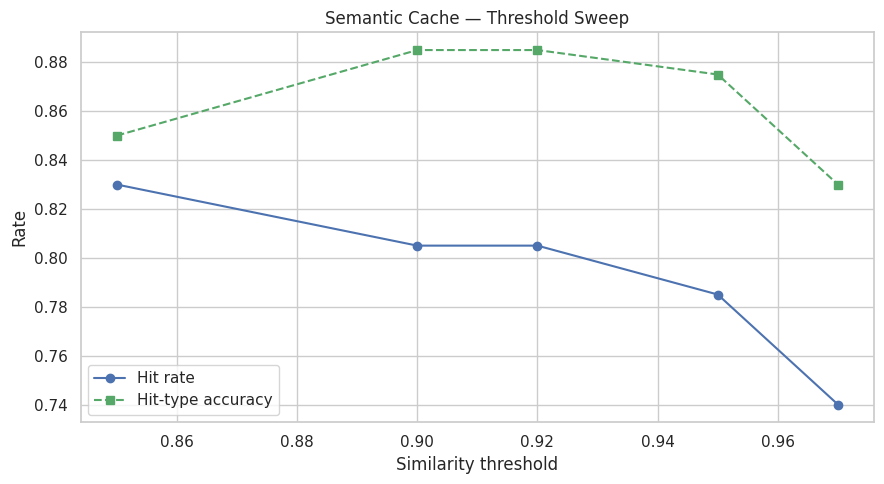

In [40]:
def light_paraphrase(q: str, rng: random.Random) -> str:
    '''Cheap, deterministic-ish perturbation approximating how a user re-types
    the same intent: light word-order shuffle + optional case change + dropped '?'.'''
    words = q.rstrip('?').split()
    if len(words) > 3:
        i = rng.randint(0, len(words) - 2)
        words[i], words[i + 1] = words[i + 1], words[i]
    out = " ".join(words)
    return out.lower() if rng.random() < 0.5 else out

rng_stream = random.Random(SEED)
base_pool = test_prompts_eval[: min(60, len(test_prompts_eval))]

stream, stream_labels, seen_pool = [], [], []
for _ in range(200):
    r = rng_stream.random()
    if seen_pool and r < 0.40:
        q = rng_stream.choice(seen_pool); label = "exact_repeat"
    elif seen_pool and r < 0.70:
        q = light_paraphrase(rng_stream.choice(seen_pool), rng_stream); label = "paraphrase"
    else:
        q = rng_stream.choice(base_pool); label = "new"; seen_pool.append(q)
    stream.append(q); stream_labels.append(label)

print(f"Query stream built: {len(stream)} queries  |  "
      f"{Counter(stream_labels)}")

# Precompute each UNIQUE query's generation once — the answer text and generation
# time don't depend on the cache threshold, only whether it's served from cache
# does, so this avoids re-running the (expensive) LLM generation for every
# threshold in the sweep.
unique_queries = list(dict.fromkeys(stream))
precomputed = {}
for q in tqdm(unique_queries, desc="Precomputing generations for cache benchmark"):
    t0 = time.time()
    ans = generate_response(q)
    precomputed[q] = (ans, time.time() - t0)

def benchmark_cache(threshold, stream, stream_labels):
    cache = SemanticCache(sim_threshold=threshold)
    correct_hit_type = 0
    for q, label in zip(stream, stream_labels):
        q_emb = embed_texts([q])
        cached, hit_type = cache.get(q, query_embedding=q_emb)
        expect_hit = label in ("exact_repeat", "paraphrase")
        got_hit = cached is not None
        if got_hit == expect_hit:
            correct_hit_type += 1
        if cached is None:
            ans, gen_time = precomputed[q]
            cache.put(q, ans, gen_time=gen_time, query_embedding=q_emb)
    return {
        "threshold": threshold,
        "hit_rate": round(cache.hit_rate(), 4),
        "time_saved_sec": round(cache.stats["time_saved_sec"], 2),
        "exact_hits": cache.stats["exact_hits"],
        "semantic_hits": cache.stats["semantic_hits"],
        "misses": cache.stats["misses"],
        "hit_type_accuracy": round(correct_hit_type / len(stream), 4),   # did hit/miss match the
                                                                          # intended repeat/paraphrase/new label?
    }

cache_sweep_results = [benchmark_cache(t, stream, stream_labels) for t in CACHE_THRESHOLD_SWEEP]
cache_sweep_df = pd.DataFrame(cache_sweep_results)
print("\nCache threshold sweep:")
print(cache_sweep_df.to_string(index=False))
cache_sweep_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "cache_threshold_sweep.csv"), index=False)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(cache_sweep_df["threshold"], cache_sweep_df["hit_rate"], 'o-', color="#4C72B0", label="Hit rate")
ax1.plot(cache_sweep_df["threshold"], cache_sweep_df["hit_type_accuracy"], 's--', color="#55A868", label="Hit-type accuracy")
ax1.set_xlabel("Similarity threshold"); ax1.set_ylabel("Rate")
ax1.set_title("Semantic Cache — Threshold Sweep")
ax1.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_cache_threshold_sweep.png"), dpi=150)
plt.show()


## 23 · End-to-End: Cache → Retrieve → Fine-tuned Generation

In [41]:
# build_rag_prompt() was already defined in section 20.1 (reused there for the shared
# FT+RAG generation that feeds RAGAS-lite) — re-used here unchanged.

@torch.no_grad()
def generate_answer(query: str, max_new_tokens: int = 200, use_cache: bool = True):
    t0 = time.time()

    q_emb = embed_texts([query]) if use_cache else None
    if use_cache:
        cached_answer, hit_type = query_cache.get(query, query_embedding=q_emb)
        if cached_answer is not None:
            return {"answer": cached_answer, "cache": hit_type, "retrieved": [],
                    "latency_sec": time.time() - t0}

    retrieved = hybrid_retrieve(query) if kb_chunks else []
    prompt = build_rag_prompt(query, retrieved)
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)

    gen_t0 = time.time()
    out_ids = model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=False,
        temperature=None, top_p=None, pad_token_id=tokenizer.pad_token_id,
    )
    gen_time = time.time() - gen_t0

    answer = tokenizer.decode(out_ids[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    if use_cache:
        query_cache.put(query, answer, gen_time=gen_time, query_embedding=q_emb)

    return {"answer": answer, "cache": "miss", "retrieved": retrieved, "latency_sec": time.time() - t0}

print("✅ generate_answer() ready (cache → retrieve → generate)")


✅ generate_answer() ready (cache → retrieve → generate)


### 23.1 · Smoke Test

In [42]:
test_questions_smoke = SAMPLE_QUESTIONS[:2] if "SAMPLE_QUESTIONS" in dir() else [
    "What is the last date to apply for admission at EWU?",
    "Does EWU have an internship or placement program?",
]

print("── Cold pass (cache empty) ──────────────────────────────────────────")
for q in test_questions_smoke:
    r = generate_answer(q)
    print(f"[{r['cache']:<10}] {r['latency_sec']:.2f}s  Q: {q}")
    print(f"             A: {r['answer'][:150]}")

print("\n── Warm pass (should hit cache) ─────────────────────────────────────")
for q in test_questions_smoke:
    r = generate_answer(q)
    print(f"[{r['cache']:<10}] {r['latency_sec']:.2f}s  Q: {q}")


── Cold pass (cache empty) ──────────────────────────────────────────


Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.90it/s]


[miss      ] 34.97s  Q: What is the last date to apply for admission at EWU?
             A: The last date to apply for admission is August 10, 2026. The application fee must be paid online before applying. For more details, visit the website 


Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.47it/s]


[miss      ] 34.87s  Q: Are there any evening programs available at EWU?
             A: No, the note states that no evening programs are available. Only the Orientation Program is explicitly mentioned as an evening event. The clubs list a

── Warm pass (should hit cache) ─────────────────────────────────────
[exact     ] 0.02s  Q: What is the last date to apply for admission at EWU?
[exact     ] 0.03s  Q: Are there any evening programs available at EWU?


## 24 · Full Ablation: Base vs Fine-tuned vs FT+RAG vs FT+RAG+Cache

All four systems are evaluated on the **same** `test_prompts_eval` items so the numbers are directly
comparable. `rag_predictions` / `rag_metrics` were already computed once in section 20.1 (shared with
RAGAS-lite) — reused here rather than re-generated, to avoid paying for the same LLM generations twice.
The cache row reuses FT+RAG's answers (cache never changes what gets generated, only whether it's served
from cache) and instead reports latency won on a cold→warm re-run.

Cold pass:   0%|          | 0/40 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.31it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.94it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.46it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.03it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  9.28it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.03it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.11it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.67it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.59it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  9.47it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.20it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.35it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.17it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.70it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.58it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.47it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.08it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.73it/s]

Chunks: 1

Warm pass:   0%|          | 0/40 [00:00<?, ?it/s]


                 System  ROUGE-L  chrF++  BERTScore_F1  EWU_Domain_Hit_%  Faithfulness  Avg_Latency_s
       Base (zero-shot)   0.0448  0.0888        0.6223             90.69           NaN            NaN
        Fine-tuned (FT)   0.0565  0.1509        0.5970             66.07           NaN            NaN
               FT + RAG   0.0562  0.1497        0.5958             69.97        0.0622         33.952
FT + RAG + Cache (warm)   0.0562  0.1497        0.5958             69.97        0.0622          0.022

Cache reduces average latency by 99.9% on repeated queries (warm vs cold pass).


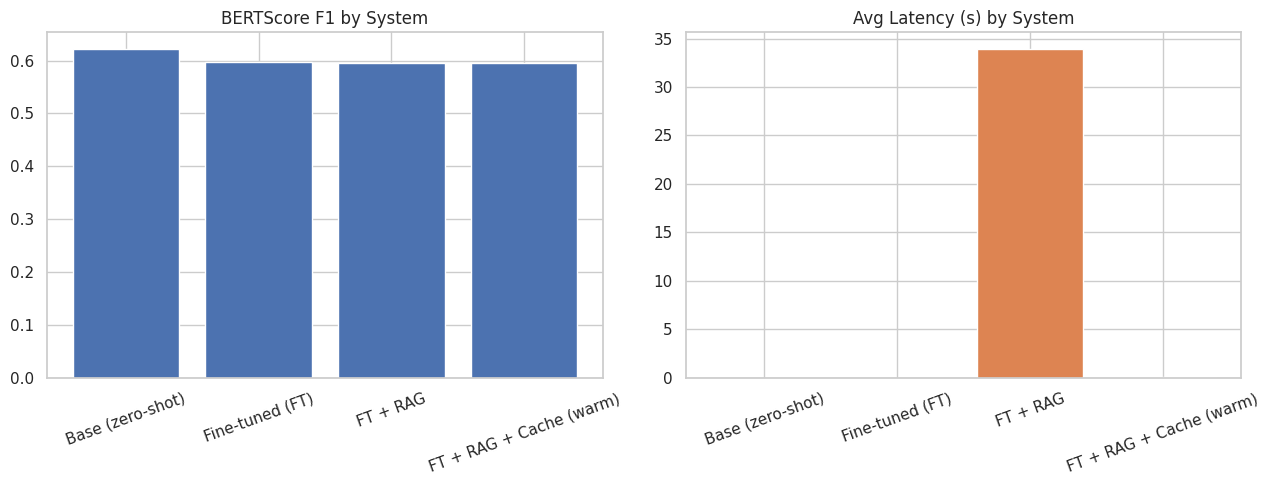

In [43]:
if kb_chunks and rag_predictions:
    # Fresh cache dedicated to this timing test: cold pass populates it, warm
    # pass re-runs the identical queries and should mostly hit.
    query_cache = SemanticCache()
    # Latency is measured on a fixed 40-query subset. In the first run the cold pass re-generated all 333 RAG
    # answers (152 min, ~27 s each) — a duplicate of §20.1 that only existed to time the cache.
    LATENCY_N = 40
    _lat_prompts = test_prompts_eval[:LATENCY_N]
    cold_latencies = [generate_answer(q, use_cache=True)["latency_sec"] for q in tqdm(_lat_prompts, desc="Cold pass")]
    warm_latencies = [generate_answer(q, use_cache=True)["latency_sec"] for q in tqdm(_lat_prompts, desc="Warm pass")]
    cache_speedup_pct = (np.mean(cold_latencies) - np.mean(warm_latencies)) / np.mean(cold_latencies) * 100

    _rag_faith = ragas_lite_metrics.get("Faithfulness")   # undefined (no retrieved context) for non-RAG rows

    ablation_table = pd.DataFrame([
        {"System": "Base (zero-shot)",        "ROUGE-L": baseline_metrics["ROUGE-L"], "chrF++": baseline_metrics["chrF++"],
         "BERTScore_F1": baseline_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": baseline_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": None, "Avg_Latency_s": None},
        {"System": "Fine-tuned (FT)",          "ROUGE-L": ft_metrics["ROUGE-L"], "chrF++": ft_metrics["chrF++"],
         "BERTScore_F1": ft_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": ft_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": None, "Avg_Latency_s": None},
        {"System": "FT + RAG",                 "ROUGE-L": rag_metrics["ROUGE-L"], "chrF++": rag_metrics["chrF++"],
         "BERTScore_F1": rag_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": rag_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": _rag_faith, "Avg_Latency_s": round(float(np.mean(cold_latencies)), 3)},
        {"System": "FT + RAG + Cache (warm)",  "ROUGE-L": rag_metrics["ROUGE-L"], "chrF++": rag_metrics["chrF++"],
         "BERTScore_F1": rag_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": rag_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": _rag_faith, "Avg_Latency_s": round(float(np.mean(warm_latencies)), 3)},
    ])

    print("\n" + ablation_table.to_string(index=False))
    print(f"\nCache reduces average latency by {cache_speedup_pct:.1f}% on repeated queries (warm vs cold pass).")
    ablation_table.to_csv(os.path.join(PAPER_ASSETS_DIR, "ablation_table.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(ablation_table["System"], ablation_table["BERTScore_F1"], color="#4C72B0")
    axes[0].set_title("BERTScore F1 by System"); axes[0].tick_params(axis='x', rotation=20)
    axes[1].bar(ablation_table["System"], ablation_table["Avg_Latency_s"].fillna(0), color="#DD8452")
    axes[1].set_title("Avg Latency (s) by System"); axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_ablation.png"), dpi=150)
    plt.show()
else:
    print("Skipping full ablation — no KB/scraped chunks were loaded, so RAG arms cannot be evaluated.")


## 24.1 · Correctness, Language-Behaviour & Consistency Evaluation (ported from `rasa-eval`)

Everything above scores answers with **overlap metrics against an English reference** (ROUGE, chrF++, BERTScore, exact match). Those can't say whether an answer is *correct*, and for Bangla/Banglish answers they compare text in another language/script to an English reference. This section adds the checks from the Rasa evaluation that were missing here, run on the **same 333 items** and the **same three systems** (Base, FT, FT+RAG):

| # | Added check | Why it matters |
|---|---|---|
| A | Response-behaviour checks: empty-response %, **script/format compliance** (Bangla query → Bangla script; English/Banglish → Latin), refusal % | A multilingual bot can answer "correctly" in the wrong script/language |
| B | **LaBSE cross-lingual semantic cosine** vs. the English ground truth | mBERT-BERTScore is unreliable across English↔Bangla; LaBSE is built for it |
| C | **0–4 LLM-judge rubric** → **Strict** (=4), **Acceptable** (≥3), **Partial-or-better** (≥2) accuracy | The primary correctness measure; the notebook had none |
| D | Accuracy tables with **bootstrap 95% CIs** + paired significance (Base→FT, FT→FT+RAG) on judge score; **English-only** lexical metrics + Token-F1 | Overlap metrics are only meaningful when the reference and answer share a language |
| E | Breakdowns by **language, difficulty, category, query style, noise type, intent, ground-truth type** | Shows *where* each system fails |
| F | **Cross-language consistency** on matched triplets (same question in EN/BN/Banglish) | Tests whether the bot is equally right in all three languages |
| G | **Failure analysis** (incorrect / partial / refusal / wrong-script cases) | Error taxonomy for the paper |
| H | **Judge-vs-human validation** (quadratic-weighted κ, agreement, P/R/F1) using the human sheets from §13.1 | Makes the automatic judge defensible |
| I | Export + merge into the ablation table | Paper-ready |

**Judge design.** To avoid loading another model on the T4, the judge is the already-loaded **Qwen2.5-3B-Instruct with the LoRA adapter disabled** (`model.disable_adapter()`), i.e. the same judge model the Rasa evaluation used. It sees only the query, the verified canonical ground truth, and the response. It runs **one response at a time** and returns a score only: in the first full run, batches of 4 with left-padding left 742 of 999 outputs unparseable (only the unpadded prompt in each batch worked), and cell C2 now stops immediately if the output is unreadable instead of silently building tables from a fraction of the data.

> ⚠️ **Caveats to state in the paper.** (1) A 3B judge is a *proxy*, not ground truth — report it as an "automatic judge" and give the validation in H. (2) The judge shares weights with the zero-shot baseline generator, so it may favour baseline-style answers; the human validation is the check on this. (3) Per-category cells contain only 9 items per system (3 difficulties × 3 languages), so treat the category table as descriptive, not inferential.
>
> If you re-run only this section, first re-run §8.1 (cell "Load Category-Stratified Eval Set") once: it now also carries `Query Style`, `Noise Type`, `Intent`, `Ground Truth Type` and `Difficulty Group`. The sampling is seeded, so it selects the **same rows in the same order** and existing predictions stay aligned.


In [44]:
# ── 24.1-A · Long-form eval table + response-behaviour checks ────────────────
import gc

BANGLA_RE = re.compile(r"[\u0980-\u09FF]")

def contains_bangla(text):
    return bool(BANGLA_RE.search(str(text or "")))

def script_format_ok(language, response):
    """Bangla query -> Bangla script expected. English/Banglish -> no Bangla script."""
    response = str(response or "").strip()
    if not response:
        return False
    has_bn = contains_bangla(response)
    return has_bn if language == "bangla" else (not has_bn)

def _qid(q):
    try:
        return int(float(q))
    except Exception:
        return str(q)

DIFFICULTY_ALIAS = {"Easy": "Simple", "Medium": "Normal", "Hard": "Complex"}

# Predictions are saved to disk below so a session crash/timeout never loses them. In a FRESH session
# (predictions not in memory) they are reloaded from that file instead of being regenerated.
PRED_CSV = os.path.join(PAPER_ASSETS_DIR, "eval_predictions_saved.csv")
_live = bool(globals().get("baseline_predictions")) and bool(globals().get("ft_predictions"))
if not _live:
    _ck = {n: os.path.join(PAPER_ASSETS_DIR, f"pred_ckpt_{n}.csv") for n in ("baseline", "ft", "rag")}
    if os.path.exists(PRED_CSV):
        _saved = pd.read_csv(PRED_CSV, keep_default_na=False)
        def _load(name):
            return _saved[_saved["system"] == name].sort_values("item_idx")["bot_response"].tolist()
        baseline_predictions, ft_predictions, rag_predictions = _load("Base (zero-shot)"), _load("Fine-tuned (FT)"), _load("FT + RAG")
        print("Loaded predictions from", PRED_CSV)
    elif os.path.exists(_ck["baseline"]) and os.path.exists(_ck["ft"]):
        def _load_ck(n):
            if not os.path.exists(_ck[n]): return []
            d = pd.read_csv(_ck[n], keep_default_na=False).sort_values("idx")
            return d["response"].tolist()
        baseline_predictions, ft_predictions, rag_predictions = _load_ck("baseline"), _load_ck("ft"), _load_ck("rag")
        print("Loaded predictions from generation checkpoints:", {k: len(v) for k, v in
              zip(("baseline", "ft", "rag"), (baseline_predictions, ft_predictions, rag_predictions))})
    else:
        raise RuntimeError("No in-memory predictions and no saved files in " + PAPER_ASSETS_DIR +
                           " — run §9/§11/§20.1 first (they generate the predictions).")

SYSTEMS = {
    "Base (zero-shot)": baseline_predictions,
    "Fine-tuned (FT)":  ft_predictions,
}
if globals().get("rag_predictions"):
    SYSTEMS["FT + RAG"] = rag_predictions

meta = xlsx_eval_df.copy().reset_index(drop=True)
if "Difficulty Group" not in meta.columns:
    meta["Difficulty Group"] = meta["Difficulty"].map(DIFFICULTY_ALIAS).fillna(meta["Difficulty"])
meta["item_idx"] = np.arange(len(meta))
meta["test_id"]  = [f"{_qid(q)}_{l}" for q, l in zip(meta["Q#"], meta["language"])]

_refusal_fn = globals().get("_looks_like_refusal", lambda t: False)

frames = []
for name, preds in SYSTEMS.items():
    assert len(preds) == len(meta), f"{name}: {len(preds)} predictions vs {len(meta)} eval items — misaligned"
    d = meta.copy()
    d["system"]       = name
    d["bot_response"] = [str(p or "").strip() for p in preds]
    d["empty_response"]       = d["bot_response"].eq("")
    d["response_word_count"]  = d["bot_response"].str.split().str.len()
    d["contains_bangla_script"] = d["bot_response"].map(contains_bangla)
    d["script_format_ok"]     = [script_format_ok(l, r) for l, r in zip(d["language"], d["bot_response"])]
    d["is_refusal"]           = [bool(_refusal_fn(r)) for r in d["bot_response"]]
    frames.append(d)

eval_long = pd.concat(frames, ignore_index=True)
eval_long[["system", "item_idx", "test_id", "bot_response"]].to_csv(
    PRED_CSV, index=False, encoding="utf-8-sig")            # <- crash-proof copy of every prediction
print("Predictions saved →", PRED_CSV)
print(f"eval_long: {len(eval_long)} rows = {len(meta)} items × {len(SYSTEMS)} systems  ({list(SYSTEMS)})")

behaviour = (
    eval_long.groupby(["system", "language"], sort=False)
    .agg(N=("test_id", "count"),
         Empty_pct=("empty_response", lambda s: 100 * s.mean()),
         Script_Format_OK_pct=("script_format_ok", lambda s: 100 * s.mean()),
         Refusal_pct=("is_refusal", lambda s: 100 * s.mean()),
         Mean_Words=("response_word_count", "mean"))
    .round(2).reset_index()
)
print("\nResponse-behaviour checks (language/script compliance, empties, refusals):")
print(behaviour.to_string(index=False))

Predictions saved → /kaggle/working/paper_assets/eval_predictions_saved.csv
eval_long: 999 rows = 333 items × 3 systems  (['Base (zero-shot)', 'Fine-tuned (FT)', 'FT + RAG'])

Response-behaviour checks (language/script compliance, empties, refusals):
          system language   N  Empty_pct  Script_Format_OK_pct  Refusal_pct  Mean_Words
Base (zero-shot)   bangla 111        0.0                100.00          0.0       29.36
Base (zero-shot)  english 111        0.0                 77.48          2.7       76.46
Base (zero-shot) banglish 111        0.0                  7.21          0.0       34.87
 Fine-tuned (FT)   bangla 111        0.0                100.00          0.0       27.46
 Fine-tuned (FT)  english 111        0.0                 95.50          0.0      125.77
 Fine-tuned (FT) banglish 111        0.0                100.00          0.0      106.41
        FT + RAG   bangla 111        0.0                100.00          0.0       27.51
        FT + RAG  english 111        0.0     

In [45]:
# ── 24.1-B · LaBSE cross-lingual semantic similarity vs English ground truth ─
# Supporting evidence, NOT the definition of correctness. If it fails, the rest of 24.1 still runs.
eval_long["Semantic_Cosine"] = np.nan

try:
    from sentence_transformers import SentenceTransformer

    free_gb = (torch.cuda.mem_get_info()[0] / 1e9) if torch.cuda.is_available() else 0.0
    labse_device = "cuda" if free_gb > 4.0 else "cpu"      # T4 is already crowded (Qwen + BGE-M3 + reranker)
    print(f"Loading LaBSE on {labse_device} (free VRAM ≈ {free_gb:.1f} GB)...")
    labse = SentenceTransformer("sentence-transformers/LaBSE", device=labse_device)

    ok = ~eval_long["empty_response"]
    resp_texts = eval_long.loc[ok, "bot_response"].tolist()
    uniq_gt    = eval_long["ground_truth"].drop_duplicates().tolist()   # each GT is reused across languages/systems
    gt_index   = {g: i for i, g in enumerate(uniq_gt)}

    resp_emb = labse.encode(resp_texts, batch_size=32, normalize_embeddings=True,
                            convert_to_numpy=True, show_progress_bar=True)
    gt_emb   = labse.encode(uniq_gt, batch_size=32, normalize_embeddings=True,
                            convert_to_numpy=True, show_progress_bar=True)

    gt_rows = np.array([gt_index[g] for g in eval_long.loc[ok, "ground_truth"]])
    eval_long.loc[ok, "Semantic_Cosine"] = np.sum(resp_emb * gt_emb[gt_rows], axis=1)   # unit vectors -> dot = cosine

    del labse, resp_emb, gt_emb
    print("✅ LaBSE semantic evaluation complete.")
    print(eval_long.groupby(["system", "language"], sort=False)["Semantic_Cosine"]
          .agg(["count", "mean", "median", "std"]).round(4))
except Exception as e:
    print("⚠️ LaBSE skipped:", type(e).__name__, str(e))
    print("Semantic_Cosine stays NaN; the judge-based accuracy below is unaffected.")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading LaBSE on cuda (free VRAM ≈ 9.3 GB)...


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ LaBSE semantic evaluation complete.
                           count    mean  median     std
system           language                               
Base (zero-shot) bangla      111  0.4297  0.4296  0.0858
                 english     111  0.5077  0.5272  0.1255
                 banglish    111  0.3708  0.3709  0.0873
Fine-tuned (FT)  bangla      111  0.4585  0.4743  0.1072
                 english     111  0.5404  0.5367  0.1220
                 banglish    111  0.4605  0.4692  0.1287
FT + RAG         bangla      111  0.4445  0.4454  0.1046
                 english     111  0.5528  0.5613  0.1316
                 banglish    111  0.4601  0.4661  0.1334


In [46]:
# ── 24.1-C1 · Judge rubric, prompt and parser ────────────────────────────────
JUDGE_SYSTEM = """You are evaluating a university information chatbot.

Use ONLY the provided canonical ground-truth answer as the factual authority.
Do not use outside knowledge.

The user query and chatbot response may be English, Bengali (Bangla),
or Banglish (Bengali written using Latin letters). Compare the meaning
of the response with the English canonical ground truth.

Rubric:
4 = Fully correct and sufficiently answers the query. No material contradiction.
3 = Core answer is correct; minor omission or harmless extra detail only.
2 = Partially correct but misses an important fact/condition or is materially incomplete.
1 = Mostly incorrect, misleading, or only tangentially relevant.
0 = Incorrect, contradictory, unrelated, or no meaningful answer.

Return ONLY valid JSON in this form (no explanation):
{"score": 4, "label": "fully_correct"}

Allowed labels:
fully_correct, mostly_correct, partially_correct, mostly_incorrect, incorrect
"""

JUDGE_PREFILL = '{"score":'   # the answer is pre-started so the model can only continue with the score
JUDGE_CHAR_CAP = 1200   # cap each field so the prompt never needs token truncation (which would cut the instructions)

def build_judge_prompt(row):
    user = (
        f"LANGUAGE: {row['language']}\n"
        f"USER QUERY:\n{str(row['query'])[:JUDGE_CHAR_CAP]}\n\n"
        f"CANONICAL GROUND TRUTH:\n{str(row['ground_truth'])[:JUDGE_CHAR_CAP]}\n\n"
        f"CHATBOT RESPONSE:\n{str(row['bot_response'])[:JUDGE_CHAR_CAP]}\n\n"
        "Judge correctness and completeness."
    )
    return (f"<|im_start|>system\n{JUDGE_SYSTEM}<|im_end|>\n"
            f"<|im_start|>user\n{user}<|im_end|>\n"
            f"<|im_start|>assistant\n{JUDGE_PREFILL}")

_JUDGE_LABELS = {0: "incorrect", 1: "mostly_incorrect", 2: "partially_correct",
                 3: "mostly_correct", 4: "fully_correct"}

def parse_judge(text):
    text = str(text).strip()
    m = re.search(r"\{.*?\}", text, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group(0))
            score = int(obj["score"])
            if score in {0, 1, 2, 3, 4}:
                return score, str(obj.get("label", "")), str(obj.get("reason", "")), text
        except Exception:
            pass
    m = re.search(r'"?score"?\s*[:=]\s*([0-4])', text)
    if m:
        score = int(m.group(1))
        return score, _JUDGE_LABELS[score], "Parser fallback", text
    return np.nan, "parse_error", "Could not parse judge output", text

print("Judge rubric/prompt/parser defined.")

Judge rubric/prompt/parser defined.


In [47]:
# ── 24.1-C2 · Run / resume the local 0–4 correctness judge ───────────────────
# Reuses the already-loaded `model` with the LoRA adapter DISABLED => plain Qwen2.5-3B-Instruct.
# Greedy decoding => deterministic. Checkpointed: safe to re-run after a crash.
#
# WHY BATCH SIZE 1: in the first full run, batches of 4 with left-padding produced unparseable output for
# 742 / 999 responses (≈ 3 of every 4: only the longest, unpadded prompt in each batch was readable).
# Single sequences need no padding, so that failure mode cannot occur. The answer is also score-only and
# pre-started with '{"score":' (a "reason" written AFTER the score cannot change the score, it only costs time).
JUDGE_BATCH_SIZE      = 1
JUDGE_MAX_NEW_TOKENS  = 32
JUDGE_CANARY_N        = 8       # judge this many first and abort immediately if the output is unreadable
JUDGE_MAX_PARSE_ERROR = 0.05    # abort (before any tables are built) if more than 5% cannot be parsed
JUDGE_CKPT = os.path.join(PAPER_ASSETS_DIR, "local_judge_checkpoint.csv")

import hashlib
# Key includes a hash of the response text: if predictions are ever regenerated (sampling differs), the
# stale judgement is NOT reused for a different answer — it is simply re-judged.
eval_long["_key"] = (eval_long["system"] + "||" + eval_long["item_idx"].astype(str) + "||" +
                     eval_long["bot_response"].map(lambda t: hashlib.md5(t.encode("utf-8")).hexdigest()[:10]))

if os.path.exists(JUDGE_CKPT):
    old = pd.read_csv(JUDGE_CKPT)
    old = old[old["judge_score"].notna()]          # unparsed rows are re-judged, never trusted
    print("Loaded judge checkpoint rows:", len(old))
else:
    old = pd.DataFrame(columns=["_key", "judge_score", "judge_label", "judge_reason", "judge_raw"])

done_keys = set(old["_key"].astype(str))
pending   = eval_long[~eval_long["_key"].isin(done_keys)]

new_rows, to_model = [], []
for _, r in pending.iterrows():
    if r["empty_response"]:
        new_rows.append({"_key": r["_key"], "judge_score": 0, "judge_label": "incorrect",
                         "judge_reason": "No usable chatbot response.", "judge_raw": ""})
    else:
        to_model.append(r)
print(f"Auto-scored 0 (empty): {len(new_rows)}   |   Need model judging: {len(to_model)}")

def _judge_generate(row):
    enc = tokenizer(build_judge_prompt(row), return_tensors="pt").to(model.device)   # ONE sequence: no padding
    with torch.inference_mode(), model.disable_adapter():
        out = model.generate(
            **enc, max_new_tokens=JUDGE_MAX_NEW_TOKENS, do_sample=False,
            temperature=None, top_p=None, top_k=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.convert_tokens_to_ids("<|im_end|>"),
        )
    return tokenizer.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True)

def _save_ckpt():
    pd.concat([old, pd.DataFrame(new_rows)], ignore_index=True) \
      .drop_duplicates("_key", keep="last").to_csv(JUDGE_CKPT, index=False, encoding="utf-8-sig")

if to_model:                              # only touch the GPU model if something actually needs judging
    _prev_cache = model.config.use_cache
    model.config.use_cache = True
    model.eval()
    judged_now = []
    try:
        for n, r in enumerate(tqdm(to_model, desc="Correctness judging")):
            raw = JUDGE_PREFILL + _judge_generate(r)
            score, label, reason, raw_full = parse_judge(raw)
            rec = {"_key": r["_key"], "judge_score": score, "judge_label": label,
                   "judge_reason": "" if reason == "Parser fallback" else reason, "judge_raw": raw_full}
            new_rows.append(rec); judged_now.append(rec)

            if n + 1 == JUDGE_CANARY_N:                       # fail fast, not after 45 minutes
                bad = [x for x in judged_now if pd.isna(x["judge_score"])]
                if len(bad) > JUDGE_CANARY_N // 4:
                    _save_ckpt()
                    raise RuntimeError(
                        f"Judge canary failed: {len(bad)}/{JUDGE_CANARY_N} outputs unparseable. Raw samples:\n" +
                        "\n".join(repr(x["judge_raw"][:200]) for x in bad[:3]) +
                        "\nSee the note at the top of this cell; do not continue to 24.1-D.")
            if (n + 1) % 25 == 0:
                _save_ckpt()
    finally:
        model.config.use_cache = _prev_cache
        _save_ckpt()
else:
    print("Nothing pending — all judgements come from the checkpoint (no GPU model needed).")

judge_results = pd.concat([old, pd.DataFrame(new_rows)], ignore_index=True).drop_duplicates("_key", keep="last")

for c in ["judge_score", "judge_label", "judge_reason", "judge_raw"]:
    if c in eval_long.columns:
        eval_long = eval_long.drop(columns=c)
eval_long = eval_long.merge(judge_results, on="_key", how="left")

js = eval_long["judge_score"]
eval_long["Strict_Correct"]     = np.where(js.notna(), (js == 4).astype(float), np.nan)   # score == 4
eval_long["Acceptable_Correct"] = np.where(js.notna(), (js >= 3).astype(float), np.nan)   # score >= 3
eval_long["Partial_or_Better"]  = np.where(js.notna(), (js >= 2).astype(float), np.nan)   # score >= 2

n_err = int(js.isna().sum())
err_rate = n_err / len(eval_long)
print(f"\nJudge parse errors: {n_err} / {len(eval_long)}  ({100*err_rate:.1f}%)")
print("\nJudge score distribution per system:")
print(pd.crosstab(eval_long["system"], eval_long["judge_score"]))

# HARD GATE: results built on a mostly-unparsed judge are worse than no results (the first run silently
# produced "accuracy" figures from only 257 of 999 items). Stop here instead of building tables.
if err_rate > JUDGE_MAX_PARSE_ERROR:
    _bad = eval_long[js.isna()]["judge_raw"].dropna().head(3).tolist()
    raise RuntimeError(f"{100*err_rate:.1f}% of judge outputs could not be parsed (limit {100*JUDGE_MAX_PARSE_ERROR:.0f}%). "
                       f"Raw samples: {[t[:160] for t in _bad]}. Do not run 24.1-D..I on this.")

Auto-scored 0 (empty): 0   |   Need model judging: 999


Correctness judging:   0%|          | 0/999 [00:00<?, ?it/s]


Judge parse errors: 0 / 999  (0.0%)

Judge score distribution per system:
judge_score       0    1    4
system                       
Base (zero-shot)  6  197  130
FT + RAG          2  183  148
Fine-tuned (FT)   2  144  187


In [48]:
# ── 24.1-D · Accuracy with bootstrap CIs, paired significance, English-only lexical ─
import unicodedata
def _boot(values):
    x = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    return bootstrap_ci(x)          # defined in §8: (mean, lo, hi), N_BOOTSTRAP resamples

def _pct(s):
    x = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(x) == 0 else 100 * x.mean()

LANGS = ["english", "bangla", "banglish"]

rows = []
for system, g in eval_long.groupby("system", sort=False):
    for scope, gg in [("Overall", g)] + [(l, g[g["language"] == l]) for l in LANGS]:
        row = {"System": system, "Scope": scope, "N": len(gg)}
        for col, lab in [("Strict_Correct", "Strict_Acc"),
                         ("Acceptable_Correct", "Acceptable_Acc"),
                         ("Partial_or_Better", "Partial_or_Better")]:
            m, lo, hi = _boot(gg[col])
            row[f"{lab}_pct"]  = round(100 * m, 2)
            row[f"{lab}_CI95"] = f"[{100*lo:.1f}, {100*hi:.1f}]"
        row["Mean_Judge_Score"]     = round(gg["judge_score"].mean(), 3)
        row["Mean_Semantic_Cosine"] = round(gg["Semantic_Cosine"].mean(), 4)
        row["Script_Format_OK_pct"] = round(_pct(gg["script_format_ok"]), 2)
        row["Empty_pct"]            = round(_pct(gg["empty_response"]), 2)
        row["Refusal_pct"]          = round(_pct(gg["is_refusal"]), 2)
        rows.append(row)

accuracy_table = pd.DataFrame(rows)
print("HEADLINE ACCURACY (judge-based, bootstrap 95% CI)\n")
print(accuracy_table[["System", "Scope", "N", "Strict_Acc_pct", "Strict_Acc_CI95",
                      "Acceptable_Acc_pct", "Acceptable_Acc_CI95",
                      "Mean_Judge_Score", "Mean_Semantic_Cosine",
                      "Script_Format_OK_pct"]].to_string(index=False))

# ── Paired significance on the SAME items ────────────────────────────────────
sig_rows = []
for a, b in [("Base (zero-shot)", "Fine-tuned (FT)"), ("Fine-tuned (FT)", "FT + RAG")]:
    if a not in SYSTEMS or b not in SYSTEMS:
        continue
    A = eval_long[eval_long["system"] == a].set_index("item_idx")
    B = eval_long[eval_long["system"] == b].set_index("item_idx")
    idx = A.index.intersection(B.index)
    idx = [i for i in idx if pd.notna(A.at[i, "judge_score"]) and pd.notna(B.at[i, "judge_score"])]
    for col, label in [("judge_score", "Mean judge score (0-4)"), ("Acceptable_Correct", "Acceptable accuracy")]:
        av, bv = A.loc[idx, col].astype(float).values, B.loc[idx, col].astype(float).values
        diff, p_boot = paired_bootstrap_p(av, bv)
        try:
            p_w = float(wilcoxon(av, bv).pvalue)
        except ValueError:                      # all paired differences are zero
            p_w = float("nan")
        sig_rows.append({"comparison": f"{a}  →  {b}", "metric": label, "n_pairs": len(idx),
                         "mean_A": round(av.mean(), 4), "mean_B": round(bv.mean(), 4),
                         "delta": round(diff, 4), "p_bootstrap": round(p_boot, 4),
                         "p_wilcoxon": None if np.isnan(p_w) else round(p_w, 4),
                         "significant_at_0.05": bool(p_boot < 0.05)})
significance_judge = pd.DataFrame(sig_rows)
print("\nPAIRED SIGNIFICANCE (judge-based)\n")
print(significance_judge.to_string(index=False) if len(significance_judge) else "n/a")

# ── English-only lexical metrics (surface overlap is only meaningful when reference & answer share a language) ─
def _norm_en(t):
    t = unicodedata.normalize("NFKC", str(t or "")).lower()
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", t)).strip()

def token_f1(pred, ref):
    p, r = _norm_en(pred).split(), _norm_en(ref).split()
    if not p and not r: return 1.0
    if not p or not r:  return 0.0
    ov = sum((Counter(p) & Counter(r)).values())
    if ov == 0: return 0.0
    pr, rc = ov / len(p), ov / len(r)
    return 2 * pr * rc / (pr + rc)

from rouge_score import rouge_scorer
import sacrebleu
_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
_chrf  = sacrebleu.CHRF(word_order=2)          # chrF++
en_sel = [i for i, l in enumerate(meta["language"]) if l == "english"]
en_refs = meta["ground_truth"].tolist()
en_rows = []
for system, preds in SYSTEMS.items():
    en_rows.append({
        "System": system, "N_english": len(en_sel),
        "ROUGE-L":  round(float(np.mean([_rouge.score(en_refs[i], preds[i])["rougeL"].fmeasure for i in en_sel])), 4),
        "chrF++":   round(float(np.mean([_chrf.sentence_score(preds[i], [en_refs[i]]).score / 100 for i in en_sel])), 4),
        "Token_F1": round(float(np.mean([token_f1(preds[i], en_refs[i]) for i in en_sel])), 4),
        "Exact_Match_%": round(100 * float(np.mean([_norm_en(preds[i]) == _norm_en(en_refs[i]) for i in en_sel])), 2),
    })
english_lexical_table = pd.DataFrame(en_rows)
print("\nENGLISH-ONLY LEXICAL METRICS (report these instead of all-language ROUGE/chrF++)\n")
print(english_lexical_table.to_string(index=False))

HEADLINE ACCURACY (judge-based, bootstrap 95% CI)

          System    Scope   N  Strict_Acc_pct Strict_Acc_CI95  Acceptable_Acc_pct Acceptable_Acc_CI95  Mean_Judge_Score  Mean_Semantic_Cosine  Script_Format_OK_pct
Base (zero-shot)  Overall 333           39.04    [33.9, 44.1]               39.04        [33.9, 44.1]             2.153                0.4361                 61.56
Base (zero-shot)  english 111           62.16    [53.2, 70.3]               62.16        [53.2, 70.3]             2.829                0.5077                 77.48
Base (zero-shot)   bangla 111           26.13    [18.9, 34.2]               26.13        [18.9, 34.2]             1.784                0.4297                100.00
Base (zero-shot) banglish 111           28.83    [20.7, 36.9]               28.83        [20.7, 36.9]             1.847                0.3708                  7.21
 Fine-tuned (FT)  Overall 333           56.16    [51.3, 61.6]               56.16        [51.3, 61.6]             2.679          


BY LANGUAGE  (Acceptable accuracy %, N per cell in the saved CSV)
system    Base (zero-shot)  FT + RAG  Fine-tuned (FT)
language                                             
bangla                26.1      28.8             29.7
banglish              28.8      50.4             65.8
english               62.2      54.1             73.0

BY DIFFICULTY  (Acceptable accuracy %, N per cell in the saved CSV)
system            Base (zero-shot)  FT + RAG  Fine-tuned (FT)
Difficulty Group                                             
Complex                       31.5      28.8             46.8
Normal                        52.3      68.5             72.1
Simple                        33.3      36.0             49.6

WEAKEST 10 CATEGORIES — Fine-tuned (n=9 items each: descriptive only)
                                                                  Category  N  Acceptable_Acc_pct Mean_Judge_Score
                                       Master in Development Studies (MDS)  9              22.222 

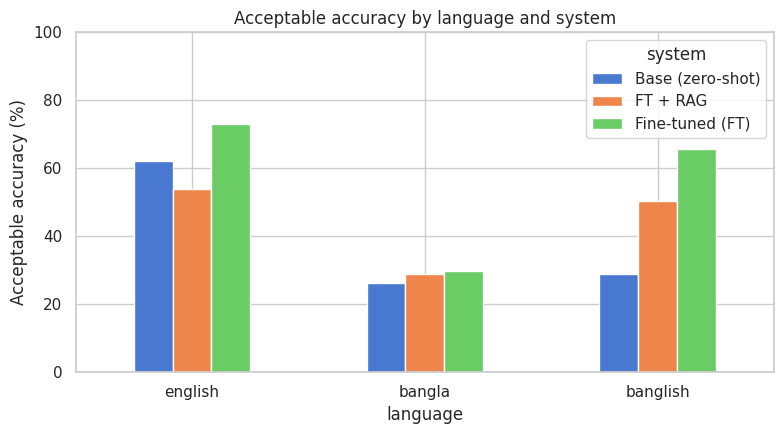

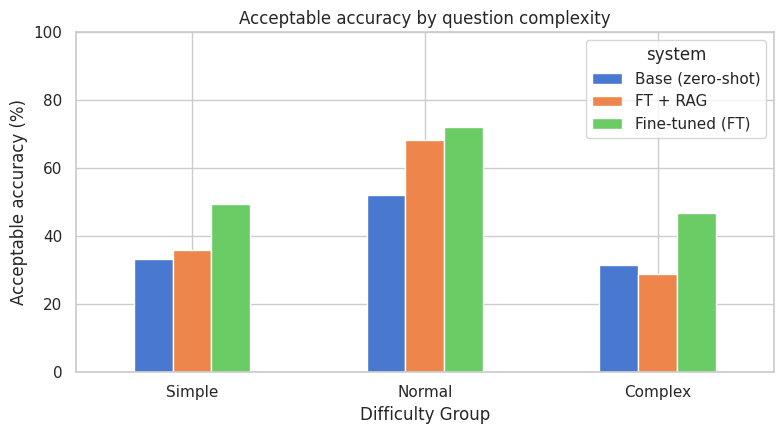

In [49]:
# ── 24.1-E · Breakdowns: language / difficulty / category / style / noise / intent / GT type ─
def summarize(df, groups):
    return (
        df.groupby(groups, dropna=False, sort=False)
        .agg(N=("test_id", "count"),
             Strict_Acc_pct=("Strict_Correct", _pct),
             Acceptable_Acc_pct=("Acceptable_Correct", _pct),
             Partial_or_Better_pct=("Partial_or_Better", _pct),
             Mean_Judge_Score=("judge_score", "mean"),
             Mean_Semantic_Cosine=("Semantic_Cosine", "mean"),
             Script_Format_OK_pct=("script_format_ok", _pct),
             Empty_pct=("empty_response", _pct))
        .reset_index().round(3)
    )

BREAKDOWN_DIMS = {
    "By Language":          ["language"],
    "By Difficulty":        ["Difficulty Group"],
    "Difficulty x Language": ["Difficulty Group", "language"],
    "By Category":          ["Category"],
    "Category x Language":  ["Category", "language"],
    "By Query Style":       ["Query Style"],
    "By Noise Type":        ["Noise Type"],
    "By Intent":            ["Intent"],
    "By GT Type":           ["Ground Truth Type"],
}

breakdowns = {}
for name, dims in BREAKDOWN_DIMS.items():
    if all(d in eval_long.columns for d in dims):
        breakdowns[name] = summarize(eval_long, ["system"] + dims)
    else:
        print(f"(skipped '{name}': column(s) {dims} not in eval set — re-run §8.1 with the patched cell)")

for name in ["By Language", "By Difficulty"]:
    if name in breakdowns:
        print(f"\n{name.upper()}  (Acceptable accuracy %, N per cell in the saved CSV)")
        dim = BREAKDOWN_DIMS[name][0]
        print(breakdowns[name].pivot(index=dim, columns="system", values="Acceptable_Acc_pct").round(1))

if "By Category" in breakdowns and "Fine-tuned (FT)" in SYSTEMS:
    cat_ft = breakdowns["By Category"].query("system == 'Fine-tuned (FT)'").sort_values("Acceptable_Acc_pct")
    print("\nWEAKEST 10 CATEGORIES — Fine-tuned (n=9 items each: descriptive only)")
    print(cat_ft[["Category", "N", "Acceptable_Acc_pct", "Mean_Judge_Score"]].head(10).to_string(index=False))

# ── Figures ──────────────────────────────────────────────────────────────────
if "By Language" in breakdowns:
    piv = breakdowns["By Language"].pivot(index="language", columns="system", values="Acceptable_Acc_pct").reindex(LANGS)
    ax = piv.plot(kind="bar", figsize=(8, 4.5), rot=0)
    ax.set_ylim(0, 100); ax.set_ylabel("Acceptable accuracy (%)"); ax.set_title("Acceptable accuracy by language and system")
    plt.tight_layout(); plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_accuracy_by_language.png"), dpi=200); plt.show()

if "By Difficulty" in breakdowns:
    piv = (breakdowns["By Difficulty"].pivot(index="Difficulty Group", columns="system", values="Acceptable_Acc_pct")
           .reindex(["Simple", "Normal", "Complex"]))
    ax = piv.plot(kind="bar", figsize=(8, 4.5), rot=0)
    ax.set_ylim(0, 100); ax.set_ylabel("Acceptable accuracy (%)"); ax.set_title("Acceptable accuracy by question complexity")
    plt.tight_layout(); plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_accuracy_by_difficulty.png"), dpi=200); plt.show()

In [50]:
# ── 24.1-F · Cross-language consistency on matched EN / BN / Banglish triplets ─
cons_rows, triplets_by_system = [], {}
for system, g in eval_long.groupby("system", sort=False):
    t = g.pivot_table(index="Q#", columns="language", values="judge_score", aggfunc="first")
    for l in LANGS:
        if l not in t.columns:
            t[l] = np.nan
    t = t[LANGS].dropna()                      # complete triplets only (parse errors dropped)
    t["All_3_Acceptable"] = (t[LANGS] >= 3).all(axis=1)
    t["All_3_Strict"]     = (t[LANGS] == 4).all(axis=1)
    t["Min_Language_Score"] = t[LANGS].min(axis=1)
    t["Cross_Language_SD"]  = t[LANGS].std(axis=1)
    triplets_by_system[system] = t.reset_index()
    cons_rows.append({
        "System": system, "N_triplets": len(t),
        "All_3_Acceptable_%": round(100 * t["All_3_Acceptable"].mean(), 2),
        "All_3_Strict_%":     round(100 * t["All_3_Strict"].mean(), 2),
        "Mean_Min_Language_Score": round(t["Min_Language_Score"].mean(), 3),
        "Mean_Cross_Language_SD":  round(t["Cross_Language_SD"].mean(), 3),
        "Gap_EN_minus_BN":       round((t["english"] - t["bangla"]).mean(), 3),
        "Gap_EN_minus_Banglish": round((t["english"] - t["banglish"]).mean(), 3),
    })

consistency_table = pd.DataFrame(cons_rows)
print("CROSS-LANGUAGE CONSISTENCY  (Gap > 0 => English scores higher than that language)\n")
print(consistency_table.to_string(index=False))

CROSS-LANGUAGE CONSISTENCY  (Gap > 0 => English scores higher than that language)

          System  N_triplets  All_3_Acceptable_%  All_3_Strict_%  Mean_Min_Language_Score  Mean_Cross_Language_SD  Gap_EN_minus_BN  Gap_EN_minus_Banglish
Base (zero-shot)         111                6.31            6.31                    1.135                   1.293            1.045                  0.982
 Fine-tuned (FT)         111               16.22           16.22                    1.468                   1.333            1.306                  0.225
        FT + RAG         111               10.81           10.81                    1.306                   1.147            0.775                  0.108


In [51]:
# ── 24.1-G · Failure analysis ────────────────────────────────────────────────
failure_summary = []
for system, g in eval_long.groupby("system", sort=False):
    wrong   = g[g["judge_score"] <= 1]
    partial = g[g["judge_score"] == 2]
    failure_summary.append({
        "System": system, "N": len(g),
        "Incorrect (score 0-1)": len(wrong),
        "Partial (score 2)": len(partial),
        "Wrong-script responses": int((~g["script_format_ok"]).sum()),
        "Refusals": int(g["is_refusal"].sum()),
        "Refusals that were also judged wrong": int(((g["judge_score"] <= 1) & g["is_refusal"]).sum()),
        "Empty responses": int(g["empty_response"].sum()),
    })
failure_summary = pd.DataFrame(failure_summary)
print(failure_summary.to_string(index=False))

_case_cols = ["system", "test_id", "language", "Category", "Difficulty", "query", "ground_truth",
              "bot_response", "judge_score", "judge_label", "judge_reason", "Semantic_Cosine"]
_case_cols = [c for c in _case_cols if c in eval_long.columns]
incorrect_cases = eval_long[eval_long["judge_score"] <= 1][_case_cols].copy()
partial_cases   = eval_long[eval_long["judge_score"] == 2][_case_cols].copy()
wrong_script_cases = eval_long[~eval_long["script_format_ok"]][_case_cols].copy()

if "Fine-tuned (FT)" in SYSTEMS:
    print("\nFive lowest-scoring Fine-tuned answers (full text in the exported workbook):")
    show = incorrect_cases.query("system == 'Fine-tuned (FT)'").head(5)
    for _, r in show.iterrows():
        print(f"\n[{r['language']}] {r['query'][:120]}\n  judge={int(r['judge_score'])}  {r['judge_reason'][:160]}")

          System   N  Incorrect (score 0-1)  Partial (score 2)  Wrong-script responses  Refusals  Refusals that were also judged wrong  Empty responses
Base (zero-shot) 333                    203                  0                     128         3                                     2                0
 Fine-tuned (FT) 333                    146                  0                       5         0                                     0                0
        FT + RAG 333                    185                  0                       1         0                                     0                0

Five lowest-scoring Fine-tuned answers (full text in the exported workbook):

[bangla] একজন শিক্ষার্থী কিস্তিতে পরিশোধের সুবিধা কীভাবে ব্যবহার করবে, অনুসরণ করবে বা সামলাবে?
  judge=1  

[bangla] আমার মোট ফল ন্যূনতম শর্ত পূরণ করলেও প্রয়োজনীয় কোনো একটি বিষয়ের ফল কম হলে কি কম্পিউটার সায়েন্স অ্যান্ড ইঞ্জিনিয়ারিংয়ে বিএ
  judge=1  

[english] How do scholarship, advising, course registration, r

In [52]:
# ── 24.1-H · Validate the automatic judge against the human annotators from §13.1 ─
# Uses the SAME annotator sheets (`human_eval_annotator*_FILLED.csv`), reading their `correctness_1to5`
# column and mapping it to the judge's 0-4 scale (human - 1). Sheets are blind to the judge, which avoids
# anchoring annotators on the automatic score.
def validate_judge_against_humans(system="Fine-tuned (FT)", min_rows=20):
    from scipy.stats import spearmanr
    from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support

    paths = sorted(glob.glob(os.path.join(PAPER_ASSETS_DIR, "human_eval_annotator*_FILLED.csv")))
    if not paths:
        print("No *_FILLED.csv annotation sheets found in paper_assets/ — skipping (run §13.1 annotation first).")
        return None

    j = eval_long[eval_long["system"] == system][["item_idx", "judge_score"]].dropna()
    out = []
    for p in paths:
        h = pd.read_csv(p)
        h["human_0_4"] = pd.to_numeric(h["correctness_1to5"], errors="coerce") - 1
        m = h[["item_id", "human_0_4"]].dropna().merge(j, left_on="item_id", right_on="item_idx")
        if len(m) < min_rows:
            print(f"{os.path.basename(p)}: only {len(m)} scored rows (< {min_rows}) — skipped.")
            continue
        hh = m["human_0_4"].round().astype(int).clip(0, 4)
        jj = m["judge_score"].astype(int)
        hb, jb = (hh >= 3).astype(int), (jj >= 3).astype(int)      # Acceptable vs not
        pr, rc, f1, _ = precision_recall_fscore_support(hb, jb, average="binary", zero_division=0)
        out.append({
            "annotator_file": os.path.basename(p), "N": len(m),
            "Exact_0-4_agreement": round(float((hh == jj).mean()), 3),
            "Quadratic_weighted_kappa": round(float(cohen_kappa_score(hh, jj, weights="quadratic")), 3),
            "Spearman_rho": round(float(spearmanr(hh, jj).correlation), 3),
            "Acceptable_agreement": round(float((hb == jb).mean()), 3),
            "Acceptable_precision": round(float(pr), 3),
            "Acceptable_recall": round(float(rc), 3),
            "Acceptable_F1": round(float(f1), 3),
        })
    return pd.DataFrame(out) if out else None

judge_validation = validate_judge_against_humans()
if judge_validation is not None:
    print(judge_validation.to_string(index=False))
    print("\nRule of thumb for the paper: quadratic-weighted κ ≥ 0.60 = substantial agreement (Landis & Koch 1977).")
    print("With ~50 items the κ interval is wide — raise N_HUMAN_EVAL_SAMPLES in §13.1 (≈150) for a tighter estimate.")
else:
    judge_validation = pd.DataFrame()

No *_FILLED.csv annotation sheets found in paper_assets/ — skipping (run §13.1 annotation first).


In [53]:
# ── 24.1-I · Export + merge correctness columns into the ablation table ──────
out_dir = PAPER_ASSETS_DIR

eval_long.drop(columns=["_key"], errors="ignore").to_csv(
    os.path.join(out_dir, "eval_long_with_judge.csv"), index=False, encoding="utf-8-sig")
accuracy_table.to_csv(os.path.join(out_dir, "accuracy_table_with_ci.csv"), index=False)
significance_judge.to_csv(os.path.join(out_dir, "judge_significance.csv"), index=False)
english_lexical_table.to_csv(os.path.join(out_dir, "english_only_lexical_metrics.csv"), index=False)
consistency_table.to_csv(os.path.join(out_dir, "cross_language_consistency.csv"), index=False)

# Ablation table + correctness columns (the cache row reuses FT+RAG answers, so it inherits FT+RAG correctness)
if "ablation_table" in globals():
    _ov = accuracy_table[accuracy_table["Scope"] == "Overall"].set_index("System")
    _cols = ["Strict_Acc_pct", "Acceptable_Acc_pct", "Mean_Judge_Score", "Mean_Semantic_Cosine", "Script_Format_OK_pct"]
    def _lookup(system_name):
        key = "FT + RAG" if str(system_name).startswith("FT + RAG") else system_name
        return _ov.loc[key, _cols] if key in _ov.index else pd.Series({c: np.nan for c in _cols})
    ablation_with_correctness = pd.concat(
        [ablation_table, ablation_table["System"].apply(_lookup)], axis=1)
    ablation_with_correctness.to_csv(os.path.join(out_dir, "ablation_table_with_correctness.csv"), index=False)
    print("Ablation table with correctness columns:\n")
    print(ablation_with_correctness.to_string(index=False))

xlsx_path = os.path.join(out_dir, "correctness_report.xlsx")
try:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
        accuracy_table.to_excel(w, sheet_name="Accuracy (CI)", index=False)
        significance_judge.to_excel(w, sheet_name="Significance", index=False)
        english_lexical_table.to_excel(w, sheet_name="English lexical", index=False)
        behaviour.to_excel(w, sheet_name="Behaviour", index=False)
        for name, df in breakdowns.items():
            df.to_excel(w, sheet_name=name[:31], index=False)
        consistency_table.to_excel(w, sheet_name="Consistency", index=False)
        for system, t in triplets_by_system.items():
            t.to_excel(w, sheet_name=f"Triplets {system.split()[0]}"[:31], index=False)
        failure_summary.to_excel(w, sheet_name="Failure summary", index=False)
        incorrect_cases.to_excel(w, sheet_name="Incorrect cases", index=False)
        partial_cases.to_excel(w, sheet_name="Partial cases", index=False)
        wrong_script_cases.to_excel(w, sheet_name="Wrong-script cases", index=False)
        if len(judge_validation):
            judge_validation.to_excel(w, sheet_name="Judge vs human", index=False)
        eval_long.drop(columns=["_key"], errors="ignore").to_excel(w, sheet_name="All results", index=False)
    print(f"\n✅ Report → {xlsx_path}")
except Exception as e:
    print("Excel export skipped:", type(e).__name__, e, "(CSV files were still written)")

print("\nNew files in paper_assets/ (included in the zip made in §25):")
for fn in ["eval_long_with_judge.csv", "accuracy_table_with_ci.csv", "judge_significance.csv",
           "english_only_lexical_metrics.csv", "cross_language_consistency.csv",
           "ablation_table_with_correctness.csv", "correctness_report.xlsx",
           "fig_accuracy_by_language.png", "fig_accuracy_by_difficulty.png"]:
    print("  ", fn, "✔" if os.path.exists(os.path.join(out_dir, fn)) else "—")

Ablation table with correctness columns:

                 System  ROUGE-L  chrF++  BERTScore_F1  EWU_Domain_Hit_%  Faithfulness  Avg_Latency_s  Strict_Acc_pct  Acceptable_Acc_pct  Mean_Judge_Score  Mean_Semantic_Cosine  Script_Format_OK_pct
       Base (zero-shot)   0.0448  0.0888        0.6223             90.69           NaN            NaN           39.04               39.04             2.153                0.4361                 61.56
        Fine-tuned (FT)   0.0565  0.1509        0.5970             66.07           NaN            NaN           56.16               56.16             2.679                0.4865                 98.50
               FT + RAG   0.0562  0.1497        0.5958             69.97        0.0622         33.952           44.44               44.44             2.327                0.4858                 99.70
FT + RAG + Cache (warm)   0.0562  0.1497        0.5958             69.97        0.0622          0.022           44.44               44.44             2.327   

## 25 · Reproducibility Appendix & Paper-Ready Export

In [54]:
# ── Compute budget (ACL/ARR Responsible-NLP-Research checklist expects this: total GPU-hours,
#    number of runs, parameter counts, and the hyperparameter configuration actually used) ────
N_GPUS = 1  # Kaggle T4 notebooks are single-GPU
total_train_seconds = sum(v.get("train_wall_sec") or 0.0 for v in seed_run_results.values())  # .get(k, default) only falls back when the KEY is missing; a resumed run stores an explicit None, so we need `or 0.0` too
total_gpu_hours = total_train_seconds / 3600.0 * N_GPUS

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_model_params = sum(p.numel() for p in model.parameters())

# T4 has a ~70W TDP; this is a rough estimate (actual draw is usually 50-90% of TDP under load),
# not a substitute for a proper measurement tool (e.g. CodeCarbon) if your venue requires one.
T4_TDP_WATTS = 70
GRID_CARBON_INTENSITY_G_PER_KWH = 475   # global average grid intensity; replace with your region's
                                          # figure (e.g. from https://ourworldindata.org/grapher/carbon-intensity-electricity)
estimated_kwh = (T4_TDP_WATTS * total_train_seconds / 3600.0) / 1000.0
estimated_co2_g = estimated_kwh * GRID_CARBON_INTENSITY_G_PER_KWH

compute_budget = {
    "n_gpus": N_GPUS,
    "gpu_type": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "unknown",
    "n_training_runs": len(RANDOM_SEEDS),
    "total_train_wall_seconds": round(total_train_seconds, 1),
    "total_gpu_hours": round(total_gpu_hours, 3),
    "trainable_parameters": trainable_params,
    "total_parameters": total_model_params,
    "trainable_parameter_pct": round(trainable_params / total_model_params * 100, 4),
    "estimated_energy_kwh": round(estimated_kwh, 4),
    "estimated_co2_g": round(estimated_co2_g, 1),
    "note": "Energy/CO2 are TDP-based estimates (T4 @ 70W, global-average grid intensity), not "
            "measured with a power meter or CodeCarbon — state this caveat if reporting them.",
}

env_info = {
    "generated_at": datetime.now().isoformat(),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "transformers_version": transformers.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "seeds": RANDOM_SEEDS,
    "hyperparameters": {
        "model_id": MODEL_ID, "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM, "learning_rate": LR, "lora_r": lora_config.r,
        "lora_alpha": lora_config.lora_alpha, "max_seq_len": MAX_SEQ_LEN,
        "hyperparameter_search": "none conducted — single configuration chosen from common "
                                  "QLoRA defaults in prior literature (Dettmers et al. 2023); "
                                  "state this explicitly rather than implying a search was run.",
    },
    "compute_budget": compute_budget,
    "data": {
        "total_pairs": len(inputs),
        "train_size": len(train_idx), "val_size": len(val_idx), "test_size": len(test_idx),
        "test_eval_subset_size": len(eval_test_idx),
        "leaked_test_examples_removed": len(leaked_test_idx),
        "leakage_similarity_threshold": LEAKAGE_SIM_THRESHOLD,
    },
    "rag": {
        "kb_chunks": len(kb_chunks), "weak_retrieval_labels": len(weak_gold),
        "weak_label_threshold": WEAK_LABEL_THRESHOLD,
    },
    "evaluation_frameworks_used": [
        "ROUGE-1/2/L (Lin, 2004)",
        "chrF++ (Popovic, 2015/2017) — via sacrebleu",
        "BERTScore F1, multilingual (Zhang et al., 2020)",
        "RAGAS-lite: local reimplementation of Faithfulness/Answer-Relevancy/Context-Precision/"
        "Context-Recall (orig. framework: Es et al., 2024)",
        "Bootstrap 95% CI + paired bootstrap significance test + Wilcoxon signed-rank",
        "Krippendorff's alpha for human-annotator agreement",
        "Optional LLM-as-judge pairwise comparison, position-bias-controlled (Zheng et al., 2023)",
        "Local 0-4 rubric LLM-judge (Qwen2.5-3B-Instruct, adapter disabled): Strict (=4) / Acceptable (>=3) / Partial (>=2) accuracy with bootstrap CIs",
        "LaBSE cross-lingual semantic cosine (Feng et al., 2022) vs English ground truth",
        "Script/format compliance, cross-language consistency on matched EN/BN/Banglish triplets",
        "Judge-vs-human validation: quadratic-weighted Cohen kappa, Spearman rho, Acceptable-agreement P/R/F1",
    ],
}
with open(os.path.join(PAPER_ASSETS_DIR, "reproducibility_appendix.json"), "w") as f:
    json.dump(env_info, f, indent=2)
print(json.dumps(env_info, indent=2))

print("\n" + "═"*70)
print("  PAPER ASSETS — everything below is ready to drop into the manuscript")
print("═"*70)
for fp in sorted(os.listdir(PAPER_ASSETS_DIR)):
    size = os.path.getsize(os.path.join(PAPER_ASSETS_DIR, fp))
    print(f"  {fp:<45s}  {size/1e3:>8.1f} KB")

paper_zip = "/kaggle/working/paper_assets.zip"
with zipfile.ZipFile(paper_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in os.listdir(PAPER_ASSETS_DIR):
        zf.write(os.path.join(PAPER_ASSETS_DIR, fp), arcname=fp)
print(f"\n✅ All paper assets zipped to {paper_zip} — download from File → Output in Kaggle.")


{
  "generated_at": "2026-09-21T15:45:11.778696",
  "python_version": "3.12.13",
  "torch_version": "2.3.1+cu121",
  "transformers_version": "4.46.3",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "seeds": [
    42
  ],
  "hyperparameters": {
    "model_id": "Qwen/Qwen2.5-3B-Instruct",
    "num_epochs": 10,
    "batch_size": 2,
    "grad_accum": 8,
    "learning_rate": 0.0002,
    "lora_r": 16,
    "lora_alpha": 32,
    "max_seq_len": 512,
    "hyperparameter_search": "none conducted \u2014 single configuration chosen from common QLoRA defaults in prior literature (Dettmers et al. 2023); state this explicitly rather than implying a search was run."
  },
  "compute_budget": {
    "n_gpus": 1,
    "gpu_type": "Tesla T4",
    "n_training_runs": 1,
    "total_train_wall_seconds": 0.0,
    "total_gpu_hours": 0.0,
    "trainable_parameters": 29933568,
    "total_parameters": 1728606208,
    "trainable_parameter_pct": 1.7317,
    "estimated_energy_kwh": 0.0,
    "estimated_co2_g": 0.0